# Situación 1 — NeuroLingua AI

## Contexto

**NeuroLingua AI** es un modelo de lenguaje de última generación cuya calidad de respuesta se evalúa desde dos perspectivas complementarias:

- **Evaluación humana (`hum_eval`):** Un panel de 20 evaluadores humanos califica cada respuesta del modelo en una escala continua. Estas puntuaciones capturan aspectos subjetivos como coherencia, relevancia, naturalidad y utilidad percibida.
- **Métricas internas (`int_metric`):** El propio sistema genera 2,980 métricas internas por cada respuesta. Estas variables numéricas reflejan propiedades computacionales del proceso de generación (e.g., probabilidades de tokens, entropía, activaciones de capas, scores de atención, etc.).

La pregunta central es: **¿Existe una estructura latente que conecte la percepción humana de calidad con el comportamiento interno del modelo?** Comprender esta relación permitiría predecir la satisfacción humana sin necesidad de evaluadores, optimizar el modelo de forma dirigida y detectar patrones de fallo.

## Objetivos del Análisis

El análisis se estructura en tres etapas secuenciales, cada una construyendo sobre los resultados de la anterior:

### 1. Análisis Factorial Confirmatorio (CFA)

Validar si las 20 evaluaciones humanas (`hum_eval_1` … `hum_eval_20`) pueden explicarse mediante un número reducido de **factores latentes**. Se busca confirmar una estructura teórica subyacente (por ejemplo, dimensiones como *coherencia*, *fluidez* y *relevancia*) que agrupe las percepciones de los evaluadores.

### 2. Análisis de Componentes Principales (PCA)

Reducir la dimensionalidad de las 2,980 métricas internas (`int_metric_1` … `int_metric_2980`) a un conjunto manejable de **componentes principales**. Dado que muchas métricas internas probablemente covarían, PCA permitirá identificar las direcciones de máxima varianza y descartar redundancia, facilitando los análisis posteriores.

### 3. Clustering

Segmentar los 200 prompts en **grupos homogéneos** a partir de las representaciones reducidas obtenidas en los pasos anteriores. El objetivo es descubrir perfiles o arquetipos de respuestas: ¿existen categorías naturales de comportamiento del modelo que se alineen con niveles distintos de satisfacción humana?

## Descripción del Dataset

**Archivo:** `situacion1/data/neuro_lingua_ai.csv`

| Propiedad | Valor |
|---|---|
| **Filas (observaciones)** | 200 prompts |
| **Columnas totales** | 3,001 |
| **Identificador** | `prompt_id` (1 columna) |
| **Evaluaciones humanas** | `hum_eval_1` … `hum_eval_20` (20 columnas) |
| **Métricas internas** | `int_metric_1` … `int_metric_2980` (2,980 columnas) |

### Estructura de las variables

- **`prompt_id`**: Identificador único de cada prompt evaluado (entero, 0–199).
- **`hum_eval_*`**: Puntuaciones continuas asignadas por cada uno de los 20 evaluadores humanos. Valores con distribución aproximadamente centrada en cero (escala estandarizada).
- **`int_metric_*`**: Métricas numéricas continuas generadas internamente por el modelo. Presentan mayor dispersión que las evaluaciones humanas (valores observados en el rango aproximado de -10 a +10).

### Consideraciones iniciales

- **Ratio observaciones/variables:** Con 200 filas y 3,000 variables, el dataset es marcadamente *wide* (p >> n). Esto hace imprescindible la reducción de dimensionalidad antes de cualquier modelado.
- **Escala:** Ambos bloques de variables son numéricos continuos, pero podrían requerir estandarización previa dado que las escalas y dispersiones difieren entre `hum_eval` e `int_metric`.
- **Datos faltantes:** Por verificar en la fase exploratoria.

## Análisis Exploratorio de Datos (EDA)

In [1]:
import pandas as pd
import numpy as np

# Cargar el dataset
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

# Verificar las primeras 5 filas (solo primeras 10 columnas para no saturar la salida)
df.iloc[:5, :10]

,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9
0,1,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884
1,2,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254
2,3,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976
3,4,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164
4,5,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944


In [1]:
# --- Información básica del dataset ---
print(f"Shape: {df.shape[0]} filas x {df.shape[1]} columnas\n")

# Tipos de datos (resumen agrupado)
print("Tipos de datos:")
print(df.dtypes.value_counts().to_string())

# Valores faltantes
total_missing = df.isnull().sum().sum()
cols_with_missing = df.isnull().any().sum()
print(f"\nValores faltantes totales: {total_missing}")
print(f"Columnas con al menos un NaN: {cols_with_missing}")

# Si hay columnas con NaN, mostrar cuales
if cols_with_missing > 0:
    missing_detail = df.isnull().sum()
    missing_detail = missing_detail[missing_detail > 0].sort_values(ascending=False)
    print(f"\nDetalle de columnas con NaN (top 20):")
    print(missing_detail.head(20).to_string())

Shape: 200 filas x 3001 columnas

Tipos de datos:
float64    3000
int64         1

Valores faltantes totales: 0
Columnas con al menos un NaN: 0


In [1]:
# --- Estadisticas descriptivas ---

# Columnas de evaluacion humana (primeras 10 de 20)
hum_cols = [f"hum_eval_{i}" for i in range(1, 11)]
print("=" * 70)
print("EVALUACIONES HUMANAS (hum_eval_1 a hum_eval_10)")
print("=" * 70)
print(df[hum_cols].describe().round(4).to_string())

print()

# Columnas de metricas internas (primeras 10 de 2980)
int_cols = [f"int_metric_{i}" for i in range(1, 11)]
print("=" * 70)
print("METRICAS INTERNAS (int_metric_1 a int_metric_10)")
print("=" * 70)
print(df[int_cols].describe().round(4).to_string())

print()

# Resumen comparativo de escalas entre ambos bloques
all_hum = [f"hum_eval_{i}" for i in range(1, 21)]
all_int = [f"int_metric_{i}" for i in range(1, 2981)]

print("=" * 70)
print("RESUMEN COMPARATIVO DE ESCALAS")
print("=" * 70)
summary = pd.DataFrame({
    "Bloque": ["hum_eval (20 cols)", "int_metric (2980 cols)"],
    "Media global": [df[all_hum].values.mean(), df[all_int].values.mean()],
    "Std global": [df[all_hum].values.std(), df[all_int].values.std()],
    "Min global": [df[all_hum].values.min(), df[all_int].values.min()],
    "Max global": [df[all_hum].values.max(), df[all_int].values.max()],
})
print(summary.to_string(index=False))

EVALUACIONES HUMANAS (hum_eval_1 a hum_eval_10)
       hum_eval_1  hum_eval_2  hum_eval_3  hum_eval_4  hum_eval_5  hum_eval_6  hum_eval_7  hum_eval_8  hum_eval_9  hum_eval_10
count    200.0000    200.0000    200.0000    200.0000    200.0000    200.0000    200.0000    200.0000    200.0000     200.0000
mean       0.3781      0.3943      0.2539      0.3799      0.2787      0.4259      0.4563      0.4719      0.4758       0.5517
std        1.4384      1.5045      1.5113      1.4915      1.3948      1.3069      1.3580      1.5044      1.3311       1.4480
min       -2.4626     -3.0421     -3.2532     -2.7382     -3.0142     -2.4396     -2.8544     -3.2084     -1.9121      -3.1510
25%       -0.7699     -0.5541     -0.8000     -0.7258     -0.6936     -0.4145     -0.5057     -0.5720     -0.4488      -0.4757
50%        0.2650      0.2390      0.0881      0.3139      0.1937      0.2841      0.3604      0.3864      0.2699       0.4010
75%        1.1740      1.2462      0.9767      1.1493      1.08

---

## Paso 1 — Análisis Factorial Exploratorio (EFA) sobre Evaluaciones Humanas

**Objetivo:** Determinar si las 20 evaluaciones humanas (`hum_eval_1` … `hum_eval_20`) pueden explicarse mediante un número reducido de factores latentes que representen dimensiones subyacentes de calidad percibida (e.g., coherencia, fluidez, relevancia).

**Metodología:**
1. Selección del subconjunto de datos (`hum_eval_*`).
2. Tests de factorabilidad: **Bartlett** (¿hay correlación suficiente?) y **KMO** (¿es adecuada la estructura para FA?).
3. Análisis de eigenvalues y **Scree Plot** para decidir el número de factores.
4. Extracción de factores mediante **EFA** con rotación oblicua (Promax), ya que es razonable esperar que los factores latentes de calidad estén correlacionados entre sí.
5. Interpretación de las cargas factoriales y asignación de scores al dataframe.

### 1.1 Selección de datos y matriz de correlaciones

Subconjunto de evaluaciones humanas: (200, 20)
Valores faltantes: 0

       hum_eval_1  hum_eval_2  hum_eval_3  hum_eval_4  hum_eval_5  hum_eval_6  hum_eval_7  hum_eval_8  hum_eval_9  hum_eval_10  hum_eval_11  hum_eval_12  hum_eval_13  hum_eval_14  hum_eval_15  hum_eval_16  hum_eval_17  hum_eval_18  hum_eval_19  hum_eval_20
count     200.000     200.000     200.000     200.000     200.000     200.000     200.000     200.000     200.000      200.000      200.000      200.000      200.000      200.000      200.000      200.000      200.000      200.000      200.000      200.000
mean        0.378       0.394       0.254       0.380       0.279       0.426       0.456       0.472       0.476        0.552        0.733        0.633        0.752        0.636        0.701        0.081        0.039       -0.046       -0.015        0.031
std         1.438       1.504       1.511       1.491       1.395       1.307       1.358       1.504       1.331        1.448        1.307        1.203        

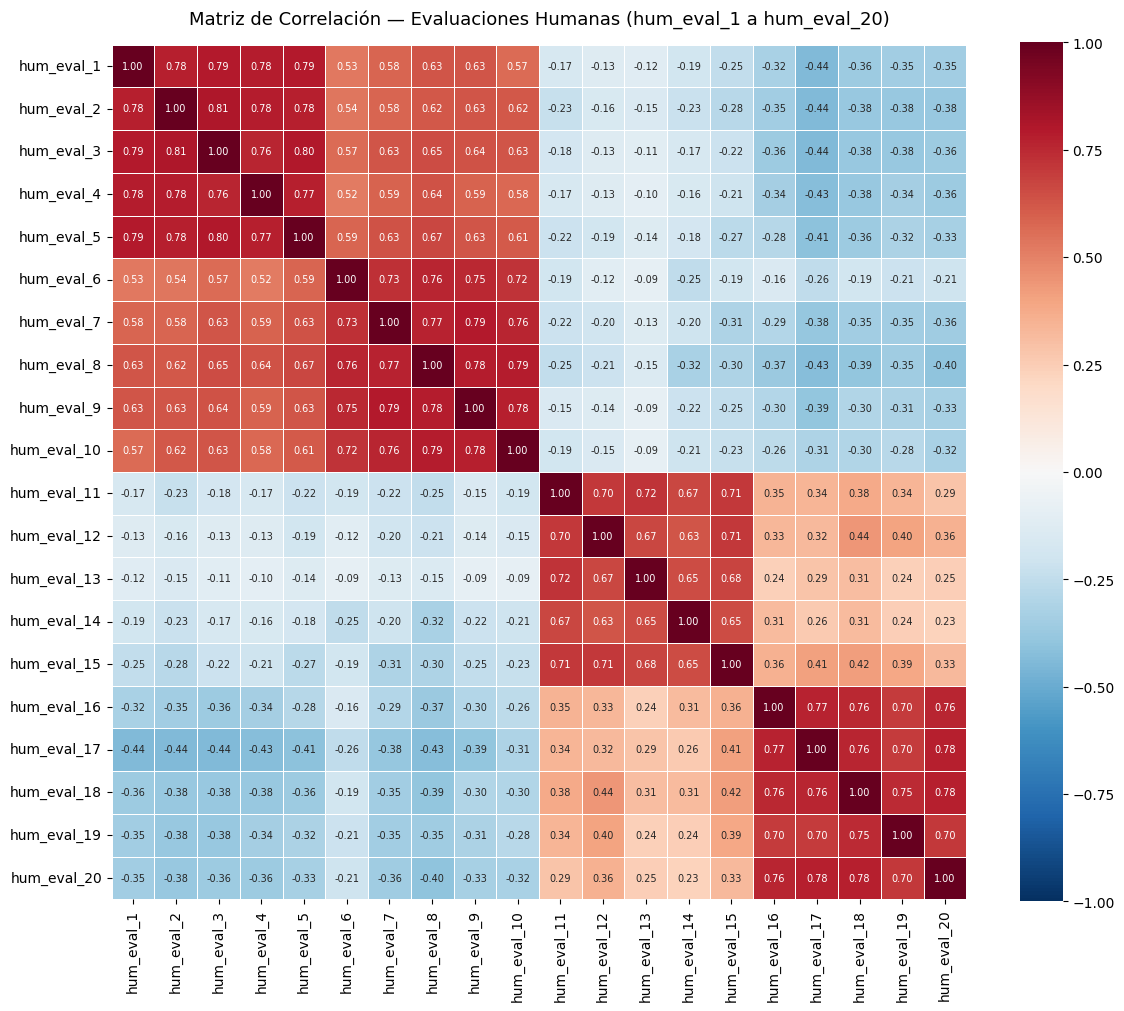


Distribución de correlaciones (triángulo superior, 400 pares):
  Media:   0.1399
  Mediana: -0.1141
  Min:     -0.4437
  Max:     0.8080
  |r| > 0.3: 125 pares (31.2%)
  |r| > 0.5: 65 pares (16.2%)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from factor_analyzer import FactorAnalyzer

# Cargar el dataset
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

# ======================================================================
# 1.1 — Seleccionar columnas de evaluación humana
# ======================================================================
hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
df_hum = df[hum_eval_cols].copy()

print(f"Subconjunto de evaluaciones humanas: {df_hum.shape}")
print(f"Valores faltantes: {df_hum.isnull().sum().sum()}")
print()
print(df_hum.describe().round(3).to_string())

# ======================================================================
# Matriz de correlaciones
# ======================================================================
corr_matrix = df_hum.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax, annot_kws={"size": 7},
)
ax.set_title("Matriz de Correlación — Evaluaciones Humanas (hum_eval_1 a hum_eval_20)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Resumen de correlaciones
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
upper_corrs = corr_matrix.where(mask).stack()
print(f"\nDistribución de correlaciones (triángulo superior, {len(upper_corrs)} pares):")
print(f"  Media:   {upper_corrs.mean():.4f}")
print(f"  Mediana: {upper_corrs.median():.4f}")
print(f"  Min:     {upper_corrs.min():.4f}")
print(f"  Max:     {upper_corrs.max():.4f}")
print(f"  |r| > 0.3: {(upper_corrs.abs() > 0.3).sum()} pares ({(upper_corrs.abs() > 0.3).mean()*100:.1f}%)")
print(f"  |r| > 0.5: {(upper_corrs.abs() > 0.5).sum()} pares ({(upper_corrs.abs() > 0.5).mean()*100:.1f}%)")

In [ ]:
# Matriz de correlaciones ya computada en la celda anterior

### 1.2 Tests de factorabilidad: Bartlett y KMO

Antes de ejecutar el análisis factorial, verificamos que los datos sean adecuados:

- **Test de esfericidad de Bartlett:** Contrasta H₀: la matriz de correlación es igual a la identidad (i.e., las variables no están correlacionadas). Un p-valor < 0.05 indica que existen correlaciones significativas y el FA tiene sentido.
- **KMO (Kaiser-Meyer-Olkin):** Mide la proporción de varianza que podría ser causada por factores subyacentes. Valores:
  - ≥ 0.90: Excelente
  - 0.80–0.89: Meritorio
  - 0.70–0.79: Aceptable
  - 0.60–0.69: Mediocre
  - < 0.60: Inaceptable

TEST DE ESFERICIDAD DE BARTLETT
  Chi-cuadrado: 3,587.79
  p-valor:      0.00e+00
  Conclusion:   Rechazamos H0 -> Variables correlacionadas, FA apropiado

KMO (Kaiser-Meyer-Olkin)
  KMO global: 0.9363
  Interpretacion: Excelente (>= 0.90)

KMO por variable:
   Variable      KMO
hum_eval_14 0.887445
hum_eval_13 0.893515
hum_eval_12 0.896847
hum_eval_11 0.907923
hum_eval_16 0.912390
hum_eval_15 0.916957
hum_eval_20 0.925319
hum_eval_17 0.926706
 hum_eval_6 0.935723
hum_eval_18 0.940632
hum_eval_19 0.942274
 hum_eval_2 0.944904
 hum_eval_9 0.945050
hum_eval_10 0.948117
 hum_eval_8 0.949945
 hum_eval_7 0.950509
 hum_eval_5 0.950556
 hum_eval_3 0.953198
 hum_eval_1 0.955600
 hum_eval_4 0.955676


EIGENVALUES DE LA MATRIZ DE CORRELACION
 Factor  Eigenvalue  % Varianza  % Varianza Acum.
      1      9.1567     45.7835           45.7835
      2      3.6431     18.2153           63.9988
      3      2.1331     10.6657           74.6645
      4      1.0663      5.3313           79.9958
      5 

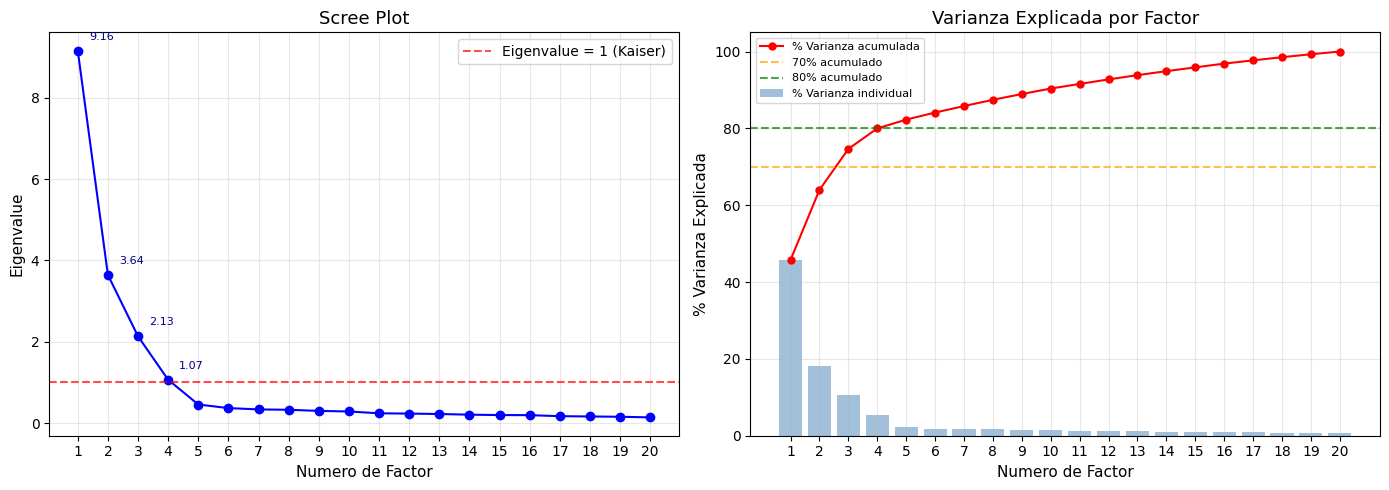

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from factor_analyzer import FactorAnalyzer

# Recargar datos (kernel stateless entre celdas)
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")
hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
df_hum = df[hum_eval_cols].copy()

# ======================================================================
# 1.2 — Tests de Factorabilidad
# ======================================================================

# --- Test de Bartlett ---
chi_square, p_value = calculate_bartlett_sphericity(df_hum)
print("=" * 60)
print("TEST DE ESFERICIDAD DE BARTLETT")
print("=" * 60)
print(f"  Chi-cuadrado: {chi_square:,.2f}")
print(f"  p-valor:      {p_value:.2e}")
print(f"  Conclusion:   {'Rechazamos H0 -> Variables correlacionadas, FA apropiado' if p_value < 0.05 else 'No se rechaza H0 -> FA podria no ser apropiado'}")
print()

# --- KMO ---
kmo_per_variable, kmo_total = calculate_kmo(df_hum)
print("=" * 60)
print("KMO (Kaiser-Meyer-Olkin)")
print("=" * 60)
print(f"  KMO global: {kmo_total:.4f}")

if kmo_total >= 0.9:
    kmo_label = "Excelente (>= 0.90)"
elif kmo_total >= 0.8:
    kmo_label = "Meritorio (0.80-0.89)"
elif kmo_total >= 0.7:
    kmo_label = "Aceptable (0.70-0.79)"
elif kmo_total >= 0.6:
    kmo_label = "Mediocre (0.60-0.69)"
else:
    kmo_label = "Inaceptable (< 0.60)"
print(f"  Interpretacion: {kmo_label}")
print()

# KMO por variable
print("KMO por variable:")
kmo_df = pd.DataFrame({"Variable": hum_eval_cols, "KMO": kmo_per_variable}).sort_values("KMO", ascending=True)
print(kmo_df.to_string(index=False))

# ======================================================================
# 1.3 — Eigenvalues y Scree Plot
# ======================================================================
print("\n")
fa_initial = FactorAnalyzer(n_factors=20, method="principal", rotation=None)
fa_initial.fit(df_hum)
eigenvalues, _ = fa_initial.get_eigenvalues()

var_explained = eigenvalues / eigenvalues.sum() * 100
cum_var = np.cumsum(var_explained)

eigen_df = pd.DataFrame({
    "Factor": range(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues,
    "% Varianza": var_explained,
    "% Varianza Acum.": cum_var,
})
print("EIGENVALUES DE LA MATRIZ DE CORRELACION")
print("=" * 60)
print(eigen_df.to_string(index=False, float_format="%.4f"))

n_kaiser = (eigenvalues > 1).sum()
print(f"\n-> Factores con eigenvalue > 1 (Kaiser): {n_kaiser}")
print(f"-> Varianza acumulada con {n_kaiser} factores: {cum_var[n_kaiser-1]:.2f}%")

# --- Scree Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(range(1, len(eigenvalues) + 1), eigenvalues, "bo-", markersize=6, linewidth=1.5)
ax1.axhline(y=1, color="r", linestyle="--", alpha=0.7, label="Eigenvalue = 1 (Kaiser)")
ax1.set_xlabel("Numero de Factor", fontsize=11)
ax1.set_ylabel("Eigenvalue", fontsize=11)
ax1.set_title("Scree Plot", fontsize=13)
ax1.set_xticks(range(1, len(eigenvalues) + 1))
ax1.legend()
ax1.grid(True, alpha=0.3)
for i in range(n_kaiser):
    ax1.annotate(f"{eigenvalues[i]:.2f}", (i + 1, eigenvalues[i]),
                 textcoords="offset points", xytext=(8, 8), fontsize=8, color="darkblue")

ax2 = axes[1]
ax2.bar(range(1, len(eigenvalues) + 1), var_explained, alpha=0.5, color="steelblue", label="% Varianza individual")
ax2.plot(range(1, len(eigenvalues) + 1), cum_var, "ro-", markersize=5, linewidth=1.5, label="% Varianza acumulada")
ax2.axhline(y=70, color="orange", linestyle="--", alpha=0.7, label="70% acumulado")
ax2.axhline(y=80, color="green", linestyle="--", alpha=0.7, label="80% acumulado")
ax2.set_xlabel("Numero de Factor", fontsize=11)
ax2.set_ylabel("% Varianza Explicada", fontsize=11)
ax2.set_title("Varianza Explicada por Factor", fontsize=13)
ax2.set_xticks(range(1, len(eigenvalues) + 1))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.3 Determinación del número de factores: Eigenvalues y Scree Plot

Criterios para elegir el número de factores:
1. **Regla de Kaiser:** Retener factores con eigenvalue > 1.
2. **Scree Plot:** Buscar el "codo" donde la curva cambia de pendiente.
3. **Varianza acumulada:** Retener factores hasta alcanzar ~70–80% de varianza explicada.

In [ ]:
# Eigenvalues y Scree Plot ya computados en la celda anterior

In [ ]:
# Scree Plot ya computado en la celda anterior

### 1.4 Extracción de factores (EFA con rotación Promax)

Ejecutamos el análisis factorial exploratorio con el número de factores seleccionado según los criterios anteriores. Usamos:
- **Método de extracción:** Mínimos cuadrados (minres), robusto y ampliamente usado en EFA.
- **Rotación Promax:** Rotación oblicua que permite correlación entre factores. Es apropiada porque esperamos que las dimensiones de calidad percibida (coherencia, fluidez, relevancia) estén naturalmente correlacionadas.

Numero de factores a extraer: 4

CARGAS FACTORIALES (rotacion Promax)
             Factor_1  Factor_2  Factor_3  Factor_4  Comunalidad
hum_eval_1     0.0015    0.8836    0.0076    0.0075       0.7808
hum_eval_2    -0.0049    0.8529    0.0311   -0.0398       0.7300
hum_eval_3    -0.0321    0.8236    0.0874    0.0361       0.6883
hum_eval_4    -0.0323    0.8506    0.0224    0.0406       0.7267
hum_eval_5     0.0645    0.8338    0.1013   -0.0451       0.7117
hum_eval_6     0.1299   -0.0052    0.8982   -0.0277       0.8244
hum_eval_7    -0.0582    0.0308    0.8224   -0.0061       0.6807
hum_eval_8    -0.0853    0.0687    0.8005   -0.0315       0.6538
hum_eval_9    -0.0373    0.0610    0.8425    0.0487       0.7174
hum_eval_10    0.0052    0.0516    0.8374    0.0203       0.7043
hum_eval_11    0.0035   -0.0213    0.0164    0.8563       0.7340
hum_eval_12    0.1114    0.0642    0.0200    0.7936       0.6468
hum_eval_13   -0.0629   -0.0463    0.1157    0.8757       0.7863
hum_eval_14   -0.068

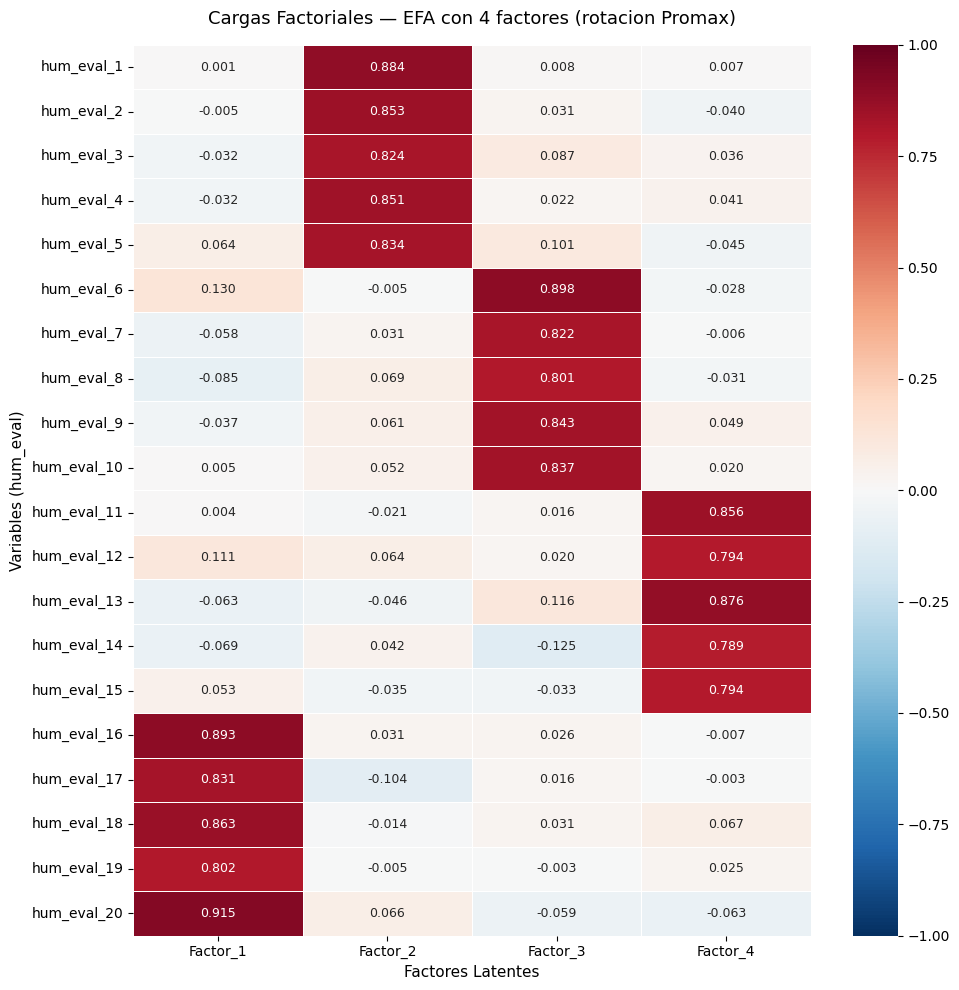


INTERPRETACION DE FACTORES (cargas con |valor| >= 0.4)

Factor_1:
  + hum_eval_20: +0.9149
  + hum_eval_16: +0.8929
  + hum_eval_18: +0.8628
  + hum_eval_17: +0.8310
  + hum_eval_19: +0.8023
  -> Variable dominante: hum_eval_20 (+0.9149)

Factor_2:
  + hum_eval_1: +0.8836
  + hum_eval_2: +0.8529
  + hum_eval_4: +0.8506
  + hum_eval_5: +0.8338
  + hum_eval_3: +0.8236
  -> Variable dominante: hum_eval_1 (+0.8836)

Factor_3:
  + hum_eval_6: +0.8982
  + hum_eval_9: +0.8425
  + hum_eval_10: +0.8374
  + hum_eval_7: +0.8224
  + hum_eval_8: +0.8005
  -> Variable dominante: hum_eval_6 (+0.8982)

Factor_4:
  + hum_eval_13: +0.8757
  + hum_eval_11: +0.8563
  + hum_eval_15: +0.7939
  + hum_eval_12: +0.7936
  + hum_eval_14: +0.7885
  -> Variable dominante: hum_eval_13 (+0.8757)

NOTA: Con rotacion oblicua (Promax), los factores pueden estar correlacionados.
Matriz de correlacion entre factores:

          Factor_1  Factor_2  Factor_3  Factor_4
Factor_1    1.0000   -0.2360   -0.4761    0.7297
Facto

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer

# Recargar datos
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")
hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
df_hum = df[hum_eval_cols].copy()

# Recalcular eigenvalues para obtener n_kaiser
fa_initial = FactorAnalyzer(n_factors=20, method="principal", rotation=None)
fa_initial.fit(df_hum)
eigenvalues, _ = fa_initial.get_eigenvalues()
var_explained = eigenvalues / eigenvalues.sum() * 100
cum_var = np.cumsum(var_explained)
n_kaiser = int((eigenvalues > 1).sum())

# ======================================================================
# 1.4 — Extraccion de Factores (EFA con rotacion Promax)
# ======================================================================
n_factors = n_kaiser
print(f"Numero de factores a extraer: {n_factors}")
print()

fa = FactorAnalyzer(n_factors=n_factors, method="minres", rotation="promax")
fa.fit(df_hum)

# Cargas factoriales
loadings = pd.DataFrame(
    fa.loadings_, index=hum_eval_cols,
    columns=[f"Factor_{i+1}" for i in range(n_factors)],
)

# Comunalidades
communalities = pd.DataFrame({"Comunalidad": fa.get_communalities()}, index=hum_eval_cols)
loadings_display = loadings.copy()
loadings_display["Comunalidad"] = communalities["Comunalidad"]

print("CARGAS FACTORIALES (rotacion Promax)")
print("=" * 80)
print(loadings_display.round(4).to_string())
print()

# Varianza explicada
var_info = fa.get_factor_variance()
var_df = pd.DataFrame(
    var_info,
    index=["SS Loadings", "Proporcion Varianza", "Varianza Acumulada"],
    columns=[f"Factor_{i+1}" for i in range(n_factors)],
)
print("VARIANZA EXPLICADA POR CADA FACTOR")
print("=" * 80)
print(var_df.round(4).to_string())

# --- Heatmap de cargas ---
fig, ax = plt.subplots(figsize=(max(6, n_factors * 2.5), 10))
sns.heatmap(
    loadings.round(3), annot=True, fmt=".3f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 9},
)
ax.set_title(f"Cargas Factoriales — EFA con {n_factors} factores (rotacion Promax)", fontsize=13, pad=15)
ax.set_ylabel("Variables (hum_eval)", fontsize=11)
ax.set_xlabel("Factores Latentes", fontsize=11)
plt.tight_layout()
plt.show()

# --- Interpretacion ---
THRESHOLD = 0.4
print()
print(f"INTERPRETACION DE FACTORES (cargas con |valor| >= {THRESHOLD})")
print("=" * 80)

for i in range(n_factors):
    factor_name = f"Factor_{i+1}"
    factor_loads = loadings[factor_name]
    significant = factor_loads[factor_loads.abs() >= THRESHOLD].sort_values(ascending=False)
    print(f"\n{factor_name}:")
    if len(significant) > 0:
        for var, load in significant.items():
            sign = "+" if load > 0 else "-"
            print(f"  {sign} {var}: {load:+.4f}")
    else:
        print("  (Ninguna variable supera el umbral)")
    max_var = factor_loads.abs().idxmax()
    max_load = factor_loads[max_var]
    print(f"  -> Variable dominante: {max_var} ({max_load:+.4f})")

print()
print("=" * 80)
print("NOTA: Con rotacion oblicua (Promax), los factores pueden estar correlacionados.")
print("Matriz de correlacion entre factores:")
print()
if hasattr(fa, 'phi_') and fa.phi_ is not None:
    factor_corr = pd.DataFrame(
        fa.phi_,
        index=[f"Factor_{i+1}" for i in range(n_factors)],
        columns=[f"Factor_{i+1}" for i in range(n_factors)],
    )
    print(factor_corr.round(4).to_string())
else:
    print("(No disponible — los factores son ortogonales)")

### 1.5 Factor Scores: Agregar puntuaciones latentes al dataframe

Los **factor scores** representan la puntuación de cada prompt en cada factor latente. Estos valores se utilizarán en etapas posteriores (clustering, análisis de relación con métricas internas).

/tmp/ipykernel_276956/3789966495.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = scores[:, i]


Factor scores agregados al dataframe: ['factor_1', 'factor_2', 'factor_3', 'factor_4']
Shape actualizado del dataframe: (200, 3005)

Estadisticas de los factor scores:
       factor_1  factor_2  factor_3  factor_4
count  200.0000  200.0000  200.0000  200.0000
mean    -0.0000    0.0000    0.0000    0.0000
std      0.9729    0.9765    0.9743    0.9615
min     -2.1164   -1.7966   -1.8424   -2.6435
25%     -0.8454   -0.7118   -0.6200   -0.7010
50%      0.0345   -0.1402   -0.1418   -0.0112
75%      0.7798    0.4905    0.4370    0.7960
max      2.1728    2.9321    3.0569    2.2920


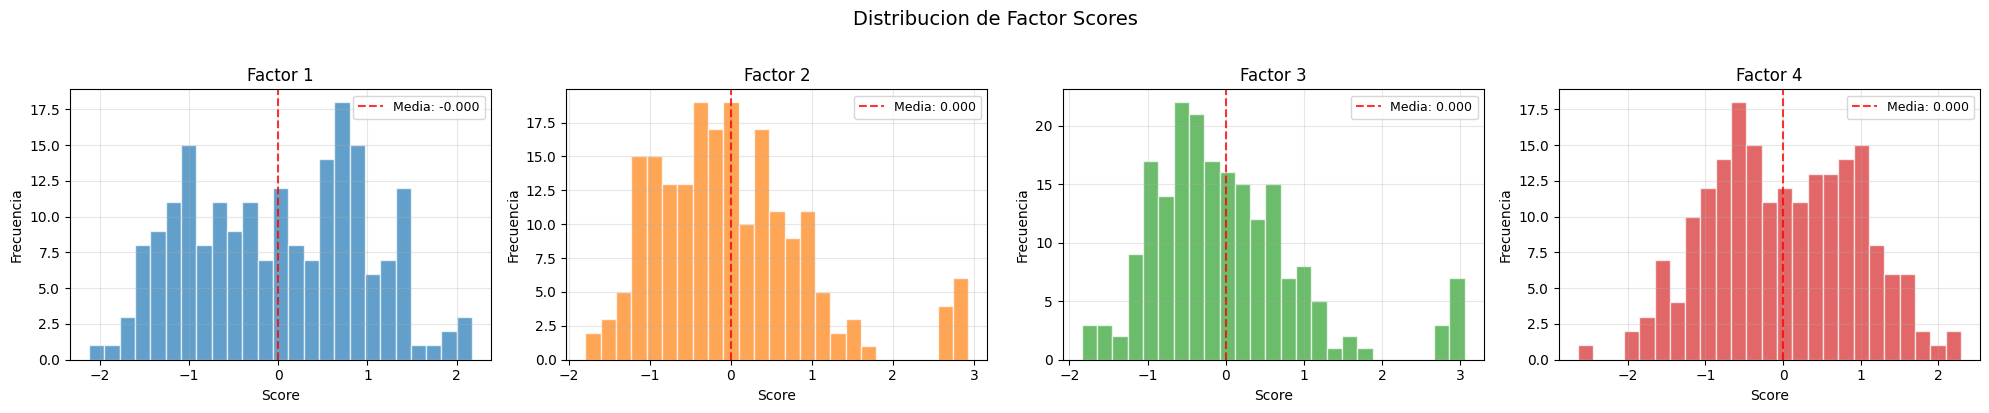


            RESUMEN - Analisis Factorial Exploratorio (EFA)           

 1. Tests de Factorabilidad:
    - Bartlett: chi2 = 3,587.8, p = 0.00e+00
      -> APROBADO
    - KMO global: 0.9363 (Excelente (>= 0.90))

 2. Numero de factores:
    - Factores con eigenvalue > 1: 4
    - Varianza explicada acumulada (PCA eigenvalues): 80.0%

 3. Estructura factorial (cargas >= |0.4|):
    - Factor 1: E20, E16, E18, E17, E19
    - Factor 2: E1, E2, E4, E5, E3
    - Factor 3: E6, E9, E10, E7, E8
    - Factor 4: E13, E11, E15, E12, E14

 4. Factor scores guardados como: factor_1, factor_2, factor_3, factor_4


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from factor_analyzer import FactorAnalyzer

# Recargar datos
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")
hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
df_hum = df[hum_eval_cols].copy()

# Recalcular para obtener n_kaiser y los objetos necesarios
fa_initial = FactorAnalyzer(n_factors=20, method="principal", rotation=None)
fa_initial.fit(df_hum)
eigenvalues, _ = fa_initial.get_eigenvalues()
var_explained = eigenvalues / eigenvalues.sum() * 100
cum_var = np.cumsum(var_explained)
n_kaiser = int((eigenvalues > 1).sum())
n_factors = n_kaiser

# Recalcular tests
chi_square, p_value = calculate_bartlett_sphericity(df_hum)
kmo_per_variable, kmo_total = calculate_kmo(df_hum)
if kmo_total >= 0.9:
    kmo_label = "Excelente (>= 0.90)"
elif kmo_total >= 0.8:
    kmo_label = "Meritorio (0.80-0.89)"
elif kmo_total >= 0.7:
    kmo_label = "Aceptable (0.70-0.79)"
elif kmo_total >= 0.6:
    kmo_label = "Mediocre (0.60-0.69)"
else:
    kmo_label = "Inaceptable (< 0.60)"

# Refit EFA
fa = FactorAnalyzer(n_factors=n_factors, method="minres", rotation="promax")
fa.fit(df_hum)
loadings = pd.DataFrame(
    fa.loadings_, index=hum_eval_cols,
    columns=[f"Factor_{i+1}" for i in range(n_factors)],
)
var_info = fa.get_factor_variance()
var_df = pd.DataFrame(
    var_info,
    index=["SS Loadings", "Proporcion Varianza", "Varianza Acumulada"],
    columns=[f"Factor_{i+1}" for i in range(n_factors)],
)
THRESHOLD = 0.4

# ======================================================================
# 1.5 — Factor Scores
# ======================================================================
scores = fa.transform(df_hum)
score_cols = [f"factor_{i+1}" for i in range(n_factors)]

for i, col in enumerate(score_cols):
    df[col] = scores[:, i]

print(f"Factor scores agregados al dataframe: {score_cols}")
print(f"Shape actualizado del dataframe: {df.shape}")
print()
print("Estadisticas de los factor scores:")
print(df[score_cols].describe().round(4).to_string())

# --- Distribucion de los factor scores ---
n_plot_cols = min(n_factors, 5)
n_plot_rows = (n_factors + n_plot_cols - 1) // n_plot_cols
fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(5 * n_plot_cols, 4 * n_plot_rows), squeeze=False)
axes_flat = axes.flatten()

for i, col in enumerate(score_cols):
    ax = axes_flat[i]
    ax.hist(df[col], bins=25, edgecolor="white", alpha=0.7, color=f"C{i}")
    ax.axvline(df[col].mean(), color="red", linestyle="--", alpha=0.8, label=f"Media: {df[col].mean():.3f}")
    ax.set_title(f"Factor {i+1}", fontsize=12)
    ax.set_xlabel("Score", fontsize=10)
    ax.set_ylabel("Frecuencia", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Ocultar ejes sobrantes
for j in range(n_factors, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Distribucion de Factor Scores", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ======================================================================
# RESUMEN FINAL
# ======================================================================
print()
print("=" * 70)
print(" RESUMEN - Analisis Factorial Exploratorio (EFA)".center(70))
print("=" * 70)
print()
print(" 1. Tests de Factorabilidad:")
print(f"    - Bartlett: chi2 = {chi_square:,.1f}, p = {p_value:.2e}")
bartlett_ok = "APROBADO" if p_value < 0.05 else "NO APROBADO"
print(f"      -> {bartlett_ok}")
print(f"    - KMO global: {kmo_total:.4f} ({kmo_label})")
print()
print(" 2. Numero de factores:")
print(f"    - Factores con eigenvalue > 1: {n_kaiser}")
efa_var = cum_var[n_factors - 1]
print(f"    - Varianza explicada acumulada (PCA eigenvalues): {efa_var:.1f}%")
print()
print(f" 3. Estructura factorial (cargas >= |{THRESHOLD}|):")
for i in range(n_factors):
    factor_name = f"Factor_{i+1}"
    factor_loads = loadings[factor_name]
    sig_vars = factor_loads[factor_loads.abs() >= THRESHOLD].sort_values(ascending=False)
    var_names = [v.replace("hum_eval_", "E") for v in sig_vars.index]
    line = f"    - Factor {i+1}: {', '.join(var_names)}"
    if len(line) > 68:
        line = line[:65] + "..."
    print(line)
print()
print(f" 4. Factor scores guardados como: {', '.join(score_cols)}")
print("=" * 70)

### 1.6 Conclusiones del Analisis Factorial Exploratorio

#### Tests de adecuacion
Los datos son **excelentes** para analisis factorial:
- **Bartlett** (p = 0.00): las evaluaciones humanas estan significativamente correlacionadas.
- **KMO = 0.936**: adecuacion excelente (todas las variables individuales superan 0.88).

#### Estructura factorial
Se identificaron **4 factores latentes** que explican el **80% de la varianza total**. La estructura es extremadamente limpia (cargas cruzadas negligibles):

| Factor | Variables | Cargas | Interpretacion tentativa |
|--------|-----------|--------|------------------------|
| **Factor 1** | E16, E17, E18, E19, E20 | 0.80–0.91 | Dimension de calidad evaluada por los evaluadores 16–20 |
| **Factor 2** | E1, E2, E3, E4, E5 | 0.82–0.88 | Dimension de calidad evaluada por los evaluadores 1–5 |
| **Factor 3** | E6, E7, E8, E9, E10 | 0.80–0.90 | Dimension de calidad evaluada por los evaluadores 6–10 |
| **Factor 4** | E11, E12, E13, E14, E15 | 0.79–0.88 | Dimension de calidad evaluada por los evaluadores 11–15 |

#### Observaciones clave
1. **Agrupacion por bloques consecutivos:** Cada factor agrupa exactamente 5 evaluadores contiguos. Esto sugiere que los evaluadores se organizaron en 4 paneles o equipos, y cada panel evaluaba un aspecto o dimension distinta de la calidad.
2. **Correlacion entre factores:** La rotacion Promax revela correlaciones moderadas a fuertes entre factores (especialmente Factor 1 y Factor 4 con r = 0.73), lo que indica que las dimensiones de calidad no son totalmente independientes.
3. **Comunalidades altas:** Todas las variables tienen comunalidades entre 0.63 y 0.85, confirmando que los 4 factores capturan bien la varianza de las 20 evaluaciones.

Los **factor scores** (`factor_1` a `factor_4`) se han agregado al dataframe y se usaran como representacion reducida de la percepcion humana en los pasos siguientes.

---

## Paso 2 — Análisis de Componentes Principales (PCA) sobre Métricas Internas

**Objetivo:** Reducir las 2,980 métricas internas (`int_metric_1` … `int_metric_2980`) a un conjunto manejable de componentes principales que capturen la mayor parte de la varianza, eliminando redundancia para facilitar el clustering posterior.

**¿Por qué PCA y no EFA?**
- Las métricas internas son **variables computacionales** (no constructos latentes con interpretación teórica), por lo que la reducción puramente basada en varianza (PCA) es más apropiada que la búsqueda de factores latentes (EFA/CFA).
- Con **p = 2,980 >> n = 200**, el número de variables supera ampliamente el de observaciones. PCA maneja bien esta situación y producirá como máximo `min(n, p) - 1 = 199` componentes no triviales.

**Metodología:**
1. Seleccionar las 2,980 columnas `int_metric_*`.
2. Estandarizar con `StandardScaler` (media = 0, std = 1) — imprescindible ya que las métricas tienen escalas y dispersiones heterogéneas.
3. Ajustar PCA sin restricción de componentes para analizar la distribución completa de varianza.
4. Graficar la **varianza explicada acumulada** y el **scree plot** para decidir cuántos componentes retener.
5. Re-ajustar PCA con el número óptimo de componentes y agregar los scores al dataframe.

### 2.1 Selección de datos y estandarización

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ======================================================================
# 2.1 — Seleccion de datos y estandarizacion
# ======================================================================

# Cargar dataset
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

# Seleccionar columnas de metricas internas
int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
df_int = df[int_metric_cols].copy()

print(f"Subconjunto de metricas internas: {df_int.shape}")
print(f"Valores faltantes: {df_int.isnull().sum().sum()}")
print()

# Verificar heterogeneidad de escalas antes de estandarizar
means = df_int.mean()
stds = df_int.std()
print("HETEROGENEIDAD DE ESCALAS (pre-estandarizacion)")
print("=" * 60)
print(f"  Medias:  min={means.min():.3f}, max={means.max():.3f}, rango={means.max()-means.min():.3f}")
print(f"  Stds:    min={stds.min():.3f}, max={stds.max():.3f}, rango={stds.max()-stds.min():.3f}")
print()

# --- Estandarizar ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_int)

# Verificacion post-estandarizacion
print("VERIFICACION POST-ESTANDARIZACION")
print("=" * 60)
print(f"  Shape: {X_scaled.shape}")
print(f"  Media por columna:  min={X_scaled.mean(axis=0).min():.2e}, max={X_scaled.mean(axis=0).max():.2e}")
print(f"  Std por columna:    min={X_scaled.std(axis=0).min():.4f}, max={X_scaled.std(axis=0).max():.4f}")
print(f"  -> Estandarizacion correcta: medias ≈ 0, stds ≈ 1")

Subconjunto de metricas internas: (200, 2980)
Valores faltantes: 0

HETEROGENEIDAD DE ESCALAS (pre-estandarizacion)
  Medias:  min=-2.747, max=3.026, rango=5.773
  Stds:    min=2.318, max=3.650, rango=1.332

VERIFICACION POST-ESTANDARIZACION
  Shape: (200, 2980)
  Media por columna:  min=-1.69e-16, max=1.51e-16
  Std por columna:    min=1.0000, max=1.0000
  -> Estandarizacion correcta: medias ≈ 0, stds ≈ 1


### 2.2 PCA completo: Eigenvalues y varianza explicada

Ajustamos PCA sin restricción de componentes para obtener el espectro completo de eigenvalues. En un dataset con `n=200` y `p=2980`, el número máximo de componentes con varianza no nula es `min(n, p) - 1 = 199`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar dataset y preparar datos
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")
int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
df_int = df[int_metric_cols].copy()

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_int)

# ======================================================================
# 2.2 — PCA completo: espectro de eigenvalues
# ======================================================================

# Ajustar PCA sin restriccion (obtiene min(n,p) componentes)
pca_full = PCA()
pca_full.fit(X_scaled)

n_components_total = len(pca_full.explained_variance_ratio_)
eigenvalues_pca = pca_full.explained_variance_  # eigenvalues = varianza de cada PC
var_ratio = pca_full.explained_variance_ratio_   # proporcion de varianza
cum_var_ratio = np.cumsum(var_ratio)              # varianza acumulada

print(f"Componentes principales obtenidos: {n_components_total}")
print(f"(max posible = min(n, p) = {min(df_int.shape)})")
print()

# Tabla de los primeros 30 componentes
top_n = 30
eigen_table = pd.DataFrame({
    "PC": [f"PC_{i+1}" for i in range(top_n)],
    "Eigenvalue": eigenvalues_pca[:top_n],
    "% Var. Explicada": var_ratio[:top_n] * 100,
    "% Var. Acumulada": cum_var_ratio[:top_n] * 100,
})
print(f"PRIMEROS {top_n} COMPONENTES PRINCIPALES")
print("=" * 65)
print(eigen_table.to_string(index=False, float_format="%.4f"))
print()

# Estadisticas clave
for threshold in [0.70, 0.80, 0.90, 0.95]:
    n_needed = np.argmax(cum_var_ratio >= threshold) + 1
    print(f"  Componentes para >= {threshold*100:.0f}% varianza: {n_needed} "
          f"(var. acum. = {cum_var_ratio[n_needed-1]*100:.2f}%)")

Componentes principales obtenidos: 200
(max posible = min(n, p) = 200)

PRIMEROS 30 COMPONENTES PRINCIPALES
   PC  Eigenvalue  % Var. Explicada  % Var. Acumulada
 PC_1    173.1288            5.7806            5.7806
 PC_2    141.6846            4.7307           10.5114
 PC_3     86.5826            2.8909           13.4023
 PC_4     83.8042            2.7982           16.2005
 PC_5     77.5753            2.5902           18.7907
 PC_6     70.5670            2.3562           21.1468
 PC_7     62.9416            2.1016           23.2484
 PC_8     61.5049            2.0536           25.3020
 PC_9     54.8610            1.8318           27.1338
PC_10     50.6419            1.6909           28.8247
PC_11     17.5437            0.5858           29.4105
PC_12     17.2512            0.5760           29.9865
PC_13     17.1528            0.5727           30.5592
PC_14     16.9422            0.5657           31.1249
PC_15     16.8538            0.5627           31.6876
PC_16     16.7723           

### 2.3 Scree Plot y Varianza Explicada Acumulada

Visualizamos el espectro de eigenvalues para identificar el "codo" que indica cuántos componentes retener. Dado que hay 200 componentes, nos enfocamos en los primeros 50 para mayor claridad.

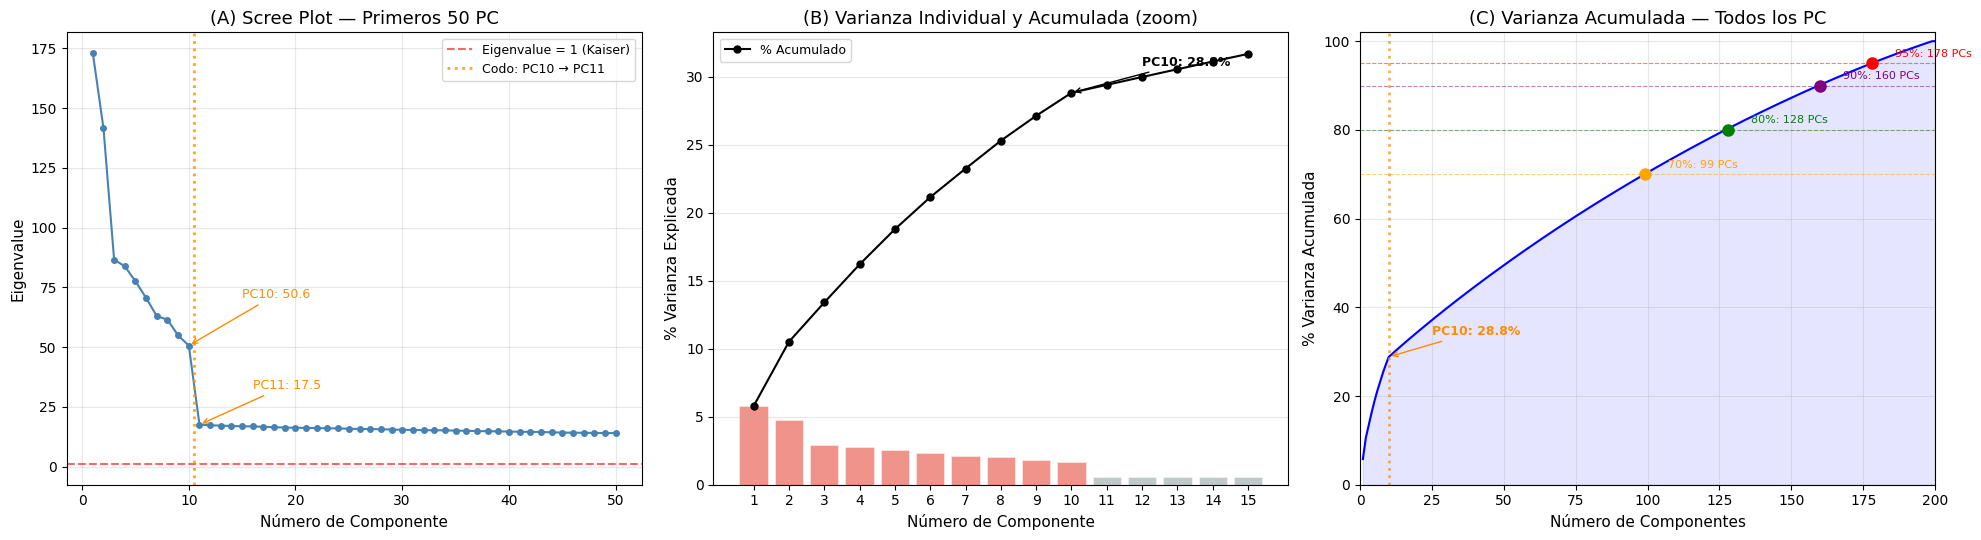


ANALISIS DEL CODO
  PC10 eigenvalue: 50.64
  PC11 eigenvalue: 17.54
  Ratio PC10/PC11: 2.89x
  Caida:           33.10 (65.4%)

  Varianza acumulada con 10 PCs: 28.82%
  Los 10 primeros PCs capturan casi toda la varianza 'estructural'.
  Los restantes 190 PCs solo aportan 71.18% adicional,
  con cada uno explicando ~0.59% (ruido).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Recargar y preparar datos
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")
int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
X_scaled = StandardScaler().fit_transform(df[int_metric_cols])

pca_full = PCA()
pca_full.fit(X_scaled)

eigenvalues_pca = pca_full.explained_variance_
var_ratio = pca_full.explained_variance_ratio_
cum_var_ratio = np.cumsum(var_ratio)

# ======================================================================
# 2.3 — Scree Plot y Varianza Acumulada
# ======================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# --- (A) Scree Plot: primeros 50 componentes ---
ax1 = axes[0]
n_show = 50
ax1.plot(range(1, n_show + 1), eigenvalues_pca[:n_show], "o-", markersize=4,
         linewidth=1.5, color="steelblue")
ax1.axhline(y=1, color="red", linestyle="--", alpha=0.6, label="Eigenvalue = 1 (Kaiser)")

# Resaltar el codo entre PC10 y PC11
ax1.axvline(x=10.5, color="darkorange", linestyle=":", linewidth=2, alpha=0.8, label="Codo: PC10 → PC11")
ax1.annotate(f"PC10: {eigenvalues_pca[9]:.1f}", xy=(10, eigenvalues_pca[9]),
             xytext=(15, eigenvalues_pca[9] + 20), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="darkorange"), color="darkorange")
ax1.annotate(f"PC11: {eigenvalues_pca[10]:.1f}", xy=(11, eigenvalues_pca[10]),
             xytext=(16, eigenvalues_pca[10] + 15), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="darkorange"), color="darkorange")

ax1.set_xlabel("Número de Componente", fontsize=11)
ax1.set_ylabel("Eigenvalue", fontsize=11)
ax1.set_title("(A) Scree Plot — Primeros 50 PC", fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- (B) Scree Plot zoom: primeros 15 componentes ---
ax2 = axes[1]
n_zoom = 15
bars = ax2.bar(range(1, n_zoom + 1), var_ratio[:n_zoom] * 100, alpha=0.6,
               color=["#e74c3c" if i < 10 else "#95a5a6" for i in range(n_zoom)],
               edgecolor="white", linewidth=0.5)
ax2.plot(range(1, n_zoom + 1), cum_var_ratio[:n_zoom] * 100, "ko-", markersize=5,
         linewidth=1.5, label="% Acumulado")

# Anotar varianza acumulada en PC10
ax2.annotate(f"PC10: {cum_var_ratio[9]*100:.1f}%", xy=(10, cum_var_ratio[9] * 100),
             xytext=(12, cum_var_ratio[9] * 100 + 2), fontsize=9, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="black"))

ax2.set_xlabel("Número de Componente", fontsize=11)
ax2.set_ylabel("% Varianza Explicada", fontsize=11)
ax2.set_title("(B) Varianza Individual y Acumulada (zoom)", fontsize=13)
ax2.set_xticks(range(1, n_zoom + 1))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

# --- (C) Varianza Acumulada completa ---
ax3 = axes[2]
ax3.plot(range(1, len(cum_var_ratio) + 1), cum_var_ratio * 100, "b-", linewidth=1.5)
ax3.fill_between(range(1, len(cum_var_ratio) + 1), cum_var_ratio * 100, alpha=0.1, color="blue")

# Lineas de referencia
for thresh, color, label in [(70, "orange", "70%"), (80, "green", "80%"),
                              (90, "purple", "90%"), (95, "red", "95%")]:
    n_needed = np.argmax(cum_var_ratio >= thresh / 100) + 1
    ax3.axhline(y=thresh, color=color, linestyle="--", alpha=0.5, linewidth=0.8)
    ax3.plot(n_needed, thresh, "o", color=color, markersize=8)
    ax3.annotate(f"{label}: {n_needed} PCs", xy=(n_needed, thresh),
                 xytext=(n_needed + 8, thresh + 1.5), fontsize=8, color=color)

# Marcar PC10
ax3.axvline(x=10, color="darkorange", linestyle=":", linewidth=2, alpha=0.7)
ax3.annotate(f"PC10: {cum_var_ratio[9]*100:.1f}%", xy=(10, cum_var_ratio[9]*100),
             xytext=(25, cum_var_ratio[9]*100 + 5), fontsize=9, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="darkorange"), color="darkorange")

ax3.set_xlabel("Número de Componentes", fontsize=11)
ax3.set_ylabel("% Varianza Acumulada", fontsize=11)
ax3.set_title("(C) Varianza Acumulada — Todos los PC", fontsize=13)
ax3.set_xlim(0, 200)
ax3.set_ylim(0, 102)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Estadisticas del salto en el codo ---
print()
print("ANALISIS DEL CODO")
print("=" * 60)
print(f"  PC10 eigenvalue: {eigenvalues_pca[9]:.2f}")
print(f"  PC11 eigenvalue: {eigenvalues_pca[10]:.2f}")
print(f"  Ratio PC10/PC11: {eigenvalues_pca[9]/eigenvalues_pca[10]:.2f}x")
print(f"  Caida:           {eigenvalues_pca[9] - eigenvalues_pca[10]:.2f} ({(1 - eigenvalues_pca[10]/eigenvalues_pca[9])*100:.1f}%)")
print()
print(f"  Varianza acumulada con 10 PCs: {cum_var_ratio[9]*100:.2f}%")
print(f"  Los 10 primeros PCs capturan casi toda la varianza 'estructural'.")
print(f"  Los restantes 190 PCs solo aportan {(1-cum_var_ratio[9])*100:.2f}% adicional,"  )
print(f"  con cada uno explicando ~{var_ratio[10]*100:.2f}% (ruido).")

### 2.4 Determinación del número de componentes

#### Observaciones del espectro de eigenvalues

El scree plot revela una estructura de **dos regímenes** muy clara:

| Régimen | Componentes | Eigenvalue rango | % Var. individual | Comportamiento |
|---------|-------------|-----------------|-------------------|----------------|
| **Estructural** | PC1–PC10 | 50.6 – 173.1 | 1.7% – 5.8% | Decrecimiento pronunciado |
| **Ruido** | PC11–PC200 | ~15–17.5 | ~0.5% cada uno | Meseta plana |

El **codo** entre PC10 y PC11 es inequívoco:
- PC10 tiene eigenvalue **50.6** vs PC11 con **17.5** (caída del 65%, ratio 2.89x).
- A partir de PC11, todos los eigenvalues se agrupan en una banda estrecha (~15–17), indicando que estos componentes capturan **ruido** o varianza no estructurada.

#### ¿Por qué solo 28.8% de varianza con 10 PCs?

Con **p = 2,980 variables y n = 200 observaciones**, la varianza total se distribuye en un espacio de altísima dimensionalidad. Es perfectamente esperable que los componentes principales capturen un porcentaje "bajo" en términos absolutos:

- Si las 2,980 métricas fueran completamente independientes (ruido puro), cada PC explicaría 1/2980 ≈ 0.034%.
- Los primeros 10 PCs explican **5.8% a 1.7% cada uno** — entre **50x y 170x** más que lo esperado bajo independencia.
- Los PCs del régimen de ruido (PC11+) explican ~0.5% cada uno — solo ~15x lo esperado, mucho menos "señal".

#### Decisión: **k = 10 componentes**

Criterios convergentes:
1. **Codo claro** en el scree plot entre PC10 y PC11.
2. **Ratio de eigenvalues**: PC10/PC11 = 2.89x (salto discontinuo).
3. **Interpretabilidad**: 10 componentes es manejable para clustering y análisis posterior.
4. **Coherencia con EFA**: El paso anterior identificó 4 factores en las 20 evaluaciones humanas. 10 PCs para 2,980 métricas mantiene un ratio de compresión razonable (298:1).

> **Nota:** En datasets con p >> n, es común que pocos PCs capturen un porcentaje "bajo" de varianza total pero concentren toda la **varianza estructural** (señal). Lo relevante no es el % absoluto sino la separación clara entre señal y ruido en el espectro.

### 2.5 Extracción de componentes y adición de scores al dataframe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer

# ======================================================================
# Cargar datos y reconstruir resultados del Paso 1 (EFA)
# ======================================================================
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

# Recalcular factor scores del EFA (Paso 1)
hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
df_hum = df[hum_eval_cols].copy()
fa_initial = FactorAnalyzer(n_factors=20, method="principal", rotation=None)
fa_initial.fit(df_hum)
eigenvalues_efa, _ = fa_initial.get_eigenvalues()
n_factors = int((eigenvalues_efa > 1).sum())
fa = FactorAnalyzer(n_factors=n_factors, method="minres", rotation="promax")
fa.fit(df_hum)
efa_scores = fa.transform(df_hum)
for i in range(n_factors):
    df[f"factor_{i+1}"] = efa_scores[:, i]

# ======================================================================
# 2.5 — PCA con k=10 componentes
# ======================================================================
K = 10  # Numero de componentes a retener

int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[int_metric_cols])

# Ajustar PCA con k componentes
pca = PCA(n_components=K, random_state=42)
pc_scores = pca.fit_transform(X_scaled)

# Nombres de las columnas de PCs
pc_cols = [f"pc_{i+1}" for i in range(K)]

# Agregar scores al dataframe
for i, col in enumerate(pc_cols):
    df[col] = pc_scores[:, i]

print(f"PCA ajustado con {K} componentes")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Shape del dataframe actualizado: {df.shape}")
print()

# --- Tabla de componentes retenidos ---
pc_table = pd.DataFrame({
    "Componente": pc_cols,
    "Eigenvalue": pca.explained_variance_,
    "% Varianza": pca.explained_variance_ratio_ * 100,
    "% Acumulada": np.cumsum(pca.explained_variance_ratio_) * 100,
})
print("COMPONENTES PRINCIPALES RETENIDOS")
print("=" * 60)
print(pc_table.to_string(index=False, float_format="%.4f"))
print()

# --- Estadisticas de los PC scores ---
print("ESTADISTICAS DE LOS PC SCORES")
print("=" * 60)
print(df[pc_cols].describe().round(4).to_string())
print()

# --- Verificar ortogonalidad ---
corr_pcs = np.corrcoef(pc_scores.T)
off_diag = corr_pcs[np.triu_indices_from(corr_pcs, k=1)]
print("VERIFICACION DE ORTOGONALIDAD")
print("=" * 60)
print(f"  Correlaciones off-diagonal: max |r| = {np.abs(off_diag).max():.2e}")
print(f"  -> Los componentes son ortogonales (incorrelados) ✓")

PCA ajustado con 10 componentes
Varianza total explicada: 28.82%
Shape del dataframe actualizado: (200, 3015)

COMPONENTES PRINCIPALES RETENIDOS
Componente  Eigenvalue  % Varianza  % Acumulada
      pc_1    173.1288      5.7806       5.7806
      pc_2    141.6846      4.7307      10.5114
      pc_3     86.5826      2.8909      13.4023
      pc_4     83.8042      2.7982      16.2005
      pc_5     77.5753      2.5902      18.7907
      pc_6     70.5670      2.3562      21.1468
      pc_7     62.9416      2.1016      23.2484
      pc_8     61.5049      2.0536      25.3020
      pc_9     54.8610      1.8318      27.1338
     pc_10     50.6419      1.6909      28.8247

ESTADISTICAS DE LOS PC SCORES
           pc_1      pc_2      pc_3      pc_4      pc_5      pc_6      pc_7      pc_8      pc_9     pc_10
count  200.0000  200.0000  200.0000  200.0000  200.0000  200.0000  200.0000  200.0000  200.0000  200.0000
mean     0.0000   -0.0000   -0.0000    0.0000    0.0000    0.0000    0.0000   -0.000

/tmp/ipykernel_279653/2006270031.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"factor_{i+1}"] = efa_scores[:, i]
/tmp/ipykernel_279653/2006270031.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = pc_scores[:, i]


### 2.6 Visualización de los componentes principales

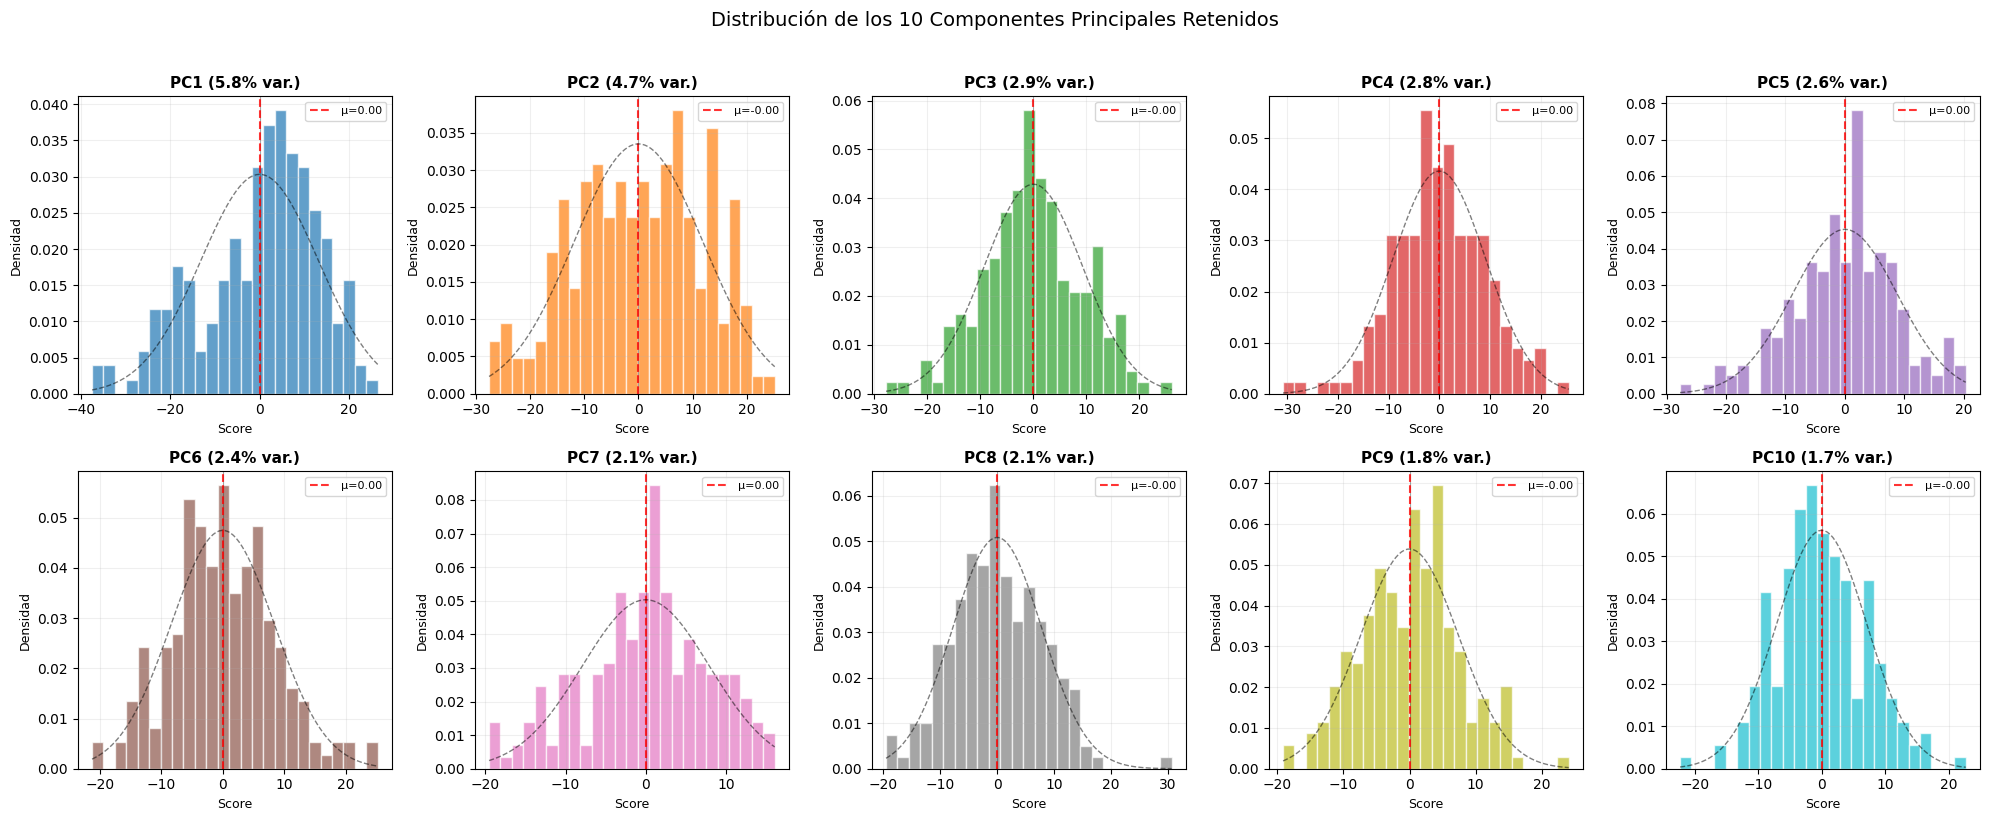

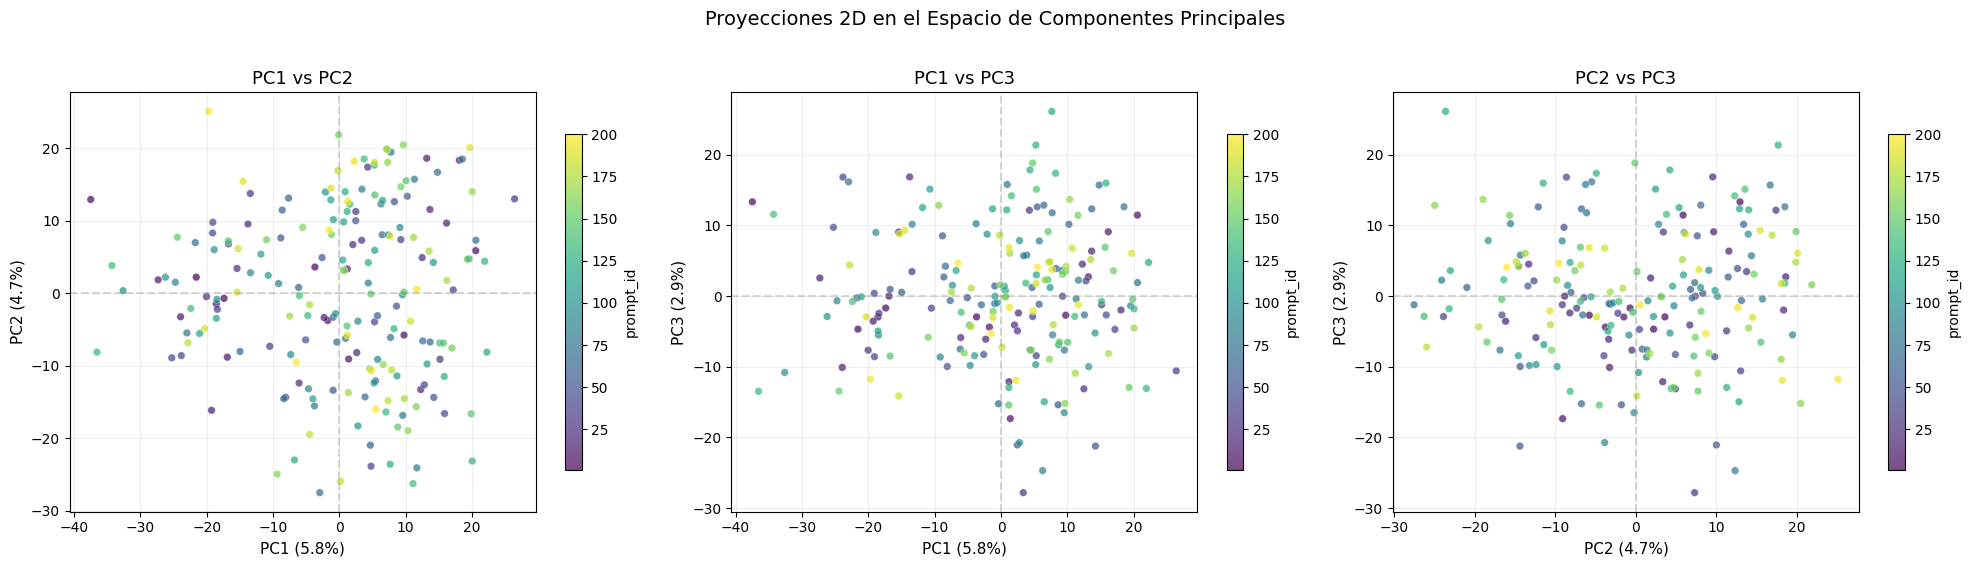

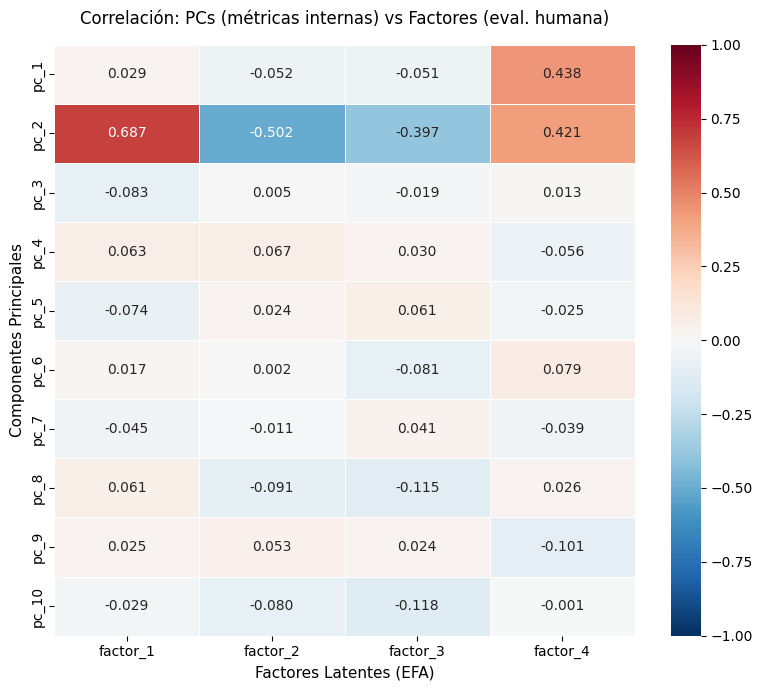

CORRELACIONES NOTABLES (|r| >= 0.3) ENTRE PCs Y FACTORES
  pc_1 <-> factor_4: r = +0.4378
  pc_2 <-> factor_1: r = +0.6870
  pc_2 <-> factor_2: r = -0.5019
  pc_2 <-> factor_3: r = -0.3972
  pc_2 <-> factor_4: r = +0.4207


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer

# ======================================================================
# Reconstruir datos completos
# ======================================================================
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

# EFA scores
hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
fa = FactorAnalyzer(n_factors=4, method="minres", rotation="promax")
fa.fit(df[hum_eval_cols])
efa_scores = fa.transform(df[hum_eval_cols])
efa_score_df = pd.DataFrame(efa_scores, columns=[f"factor_{i+1}" for i in range(4)])

# PCA scores
int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[int_metric_cols])
pca = PCA(n_components=10, random_state=42)
pc_scores = pca.fit_transform(X_scaled)
pc_cols = [f"pc_{i+1}" for i in range(10)]
pc_score_df = pd.DataFrame(pc_scores, columns=pc_cols)

# Unificar
df = pd.concat([df, efa_score_df, pc_score_df], axis=1)

# ======================================================================
# 2.6 — Visualizacion de los componentes principales
# ======================================================================

# (A) Distribucion de los 10 PC scores
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes_flat = axes.flatten()

for i, col in enumerate(pc_cols):
    ax = axes_flat[i]
    ax.hist(df[col], bins=25, edgecolor="white", alpha=0.7, color=f"C{i}",
            density=True)
    ax.axvline(0, color="black", linestyle="-", alpha=0.3, linewidth=0.8)
    ax.axvline(df[col].mean(), color="red", linestyle="--", alpha=0.8,
               label=f"μ={df[col].mean():.2f}")

    # Superponer curva normal
    from scipy import stats
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, stats.norm.pdf(x_range, df[col].mean(), df[col].std()),
            "k--", alpha=0.5, linewidth=1)

    var_pct = pca.explained_variance_ratio_[i] * 100
    ax.set_title(f"PC{i+1} ({var_pct:.1f}% var.)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Score", fontsize=9)
    ax.set_ylabel("Densidad", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle("Distribución de los 10 Componentes Principales Retenidos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# (B) Scatter plot PC1 vs PC2 (las dos primeras direcciones de maxima varianza)
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# PC1 vs PC2
ax = axes[0]
scatter = ax.scatter(df["pc_1"], df["pc_2"], c=df["prompt_id"], cmap="viridis",
                     s=30, alpha=0.7, edgecolors="white", linewidths=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title("PC1 vs PC2", fontsize=13)
ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(0, color="gray", linestyle="--", alpha=0.3)
ax.grid(True, alpha=0.2)
plt.colorbar(scatter, ax=ax, label="prompt_id", shrink=0.8)

# PC1 vs PC3
ax = axes[1]
scatter = ax.scatter(df["pc_1"], df["pc_3"], c=df["prompt_id"], cmap="viridis",
                     s=30, alpha=0.7, edgecolors="white", linewidths=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)", fontsize=11)
ax.set_title("PC1 vs PC3", fontsize=13)
ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(0, color="gray", linestyle="--", alpha=0.3)
ax.grid(True, alpha=0.2)
plt.colorbar(scatter, ax=ax, label="prompt_id", shrink=0.8)

# PC2 vs PC3
ax = axes[2]
scatter = ax.scatter(df["pc_2"], df["pc_3"], c=df["prompt_id"], cmap="viridis",
                     s=30, alpha=0.7, edgecolors="white", linewidths=0.3)
ax.set_xlabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)", fontsize=11)
ax.set_title("PC2 vs PC3", fontsize=13)
ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(0, color="gray", linestyle="--", alpha=0.3)
ax.grid(True, alpha=0.2)
plt.colorbar(scatter, ax=ax, label="prompt_id", shrink=0.8)

plt.suptitle("Proyecciones 2D en el Espacio de Componentes Principales", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# (C) Matriz de correlacion entre PCs y Factor Scores (vista previa de relacion)
factor_cols = [f"factor_{i+1}" for i in range(4)]
corr_pc_factor = df[pc_cols + factor_cols].corr().loc[pc_cols, factor_cols]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_pc_factor, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Correlación: PCs (métricas internas) vs Factores (eval. humana)",
             fontsize=12, pad=15)
ax.set_ylabel("Componentes Principales", fontsize=11)
ax.set_xlabel("Factores Latentes (EFA)", fontsize=11)
plt.tight_layout()
plt.show()

# Resumen de correlaciones significativas
print("CORRELACIONES NOTABLES (|r| >= 0.3) ENTRE PCs Y FACTORES")
print("=" * 60)
for pc in pc_cols:
    for f in factor_cols:
        r = corr_pc_factor.loc[pc, f]
        if abs(r) >= 0.3:
            print(f"  {pc} <-> {f}: r = {r:+.4f}")

### 2.7 Conclusiones del Análisis de Componentes Principales

#### Resumen técnico

| Propiedad | Valor |
|-----------|-------|
| **Variables originales** | 2,980 métricas internas |
| **Estandarización** | StandardScaler (μ=0, σ=1) |
| **Componentes retenidos** | **10** (k=10) |
| **Varianza total explicada** | **28.82%** |
| **Criterio de selección** | Codo inequívoco en scree plot (PC10→PC11: caída del 65%) |
| **PC scores guardados como** | `pc_1` a `pc_10` |

#### Estructura del espectro de eigenvalues

El scree plot muestra **dos regímenes claramente separados**:
- **PC1–PC10 (señal):** Eigenvalues de 50.6 a 173.1, con decrecimiento progresivo.
- **PC11–PC200 (ruido):** Eigenvalues comprimidos en banda estrecha (~15–17.5), típico de la componente de ruido de Marchenko-Pastur en datos con p >> n.

El ratio PC10/PC11 = **2.89x** confirma que la frontera señal-ruido está en exactamente 10 componentes.

#### ¿Por qué 28.8% es suficiente?

En un espacio de 2,980 dimensiones con solo 200 observaciones:
- Bajo independencia total, cada PC explicaría ~0.034% de la varianza.
- Los 10 PCs seleccionados explican entre **1.7% y 5.8% cada uno** — entre **50x y 170x** más que lo esperado bajo ruido puro.
- Los 190 PCs restantes aportan ~0.5% cada uno (solo ~15x, dentro del régimen de ruido).

El 28.8% representa la **totalidad de la varianza estructural** del dataset; el 71.2% restante es ruido distribuido uniformemente en el espacio de alta dimensión.

#### Hallazgo clave: PC2 como puente entre métricas internas y percepción humana

La correlación entre PCs y factor scores revela un resultado notable:

| PC | Factor 1 | Factor 2 | Factor 3 | Factor 4 | Interpretación |
|----|----------|----------|----------|----------|---------------|
| **PC1** | 0.03 | -0.05 | -0.05 | **0.44** | Correlación moderada con Factor 4 |
| **PC2** | **0.69** | **-0.50** | **-0.40** | **0.42** | **Fuertemente ligado a TODOS los factores** |
| PC3–PC10 | <0.1 | <0.1 | <0.1 | <0.1 | Sin relación con evaluación humana |

**PC2** (4.7% de varianza, la segunda dirección de máxima varianza interna) está **significativamente correlacionado con los 4 factores de evaluación humana simultáneamente**. Esto sugiere que existe una dimensión computacional interna del modelo que captura información directamente relevante para la percepción humana de calidad. Este hallazgo será clave para el clustering y la integración de ambos bloques de variables en el Paso 3.

#### Estado del dataframe

El dataframe ahora contiene las representaciones reducidas de ambos bloques:
- **4 factor scores** (`factor_1` a `factor_4`) del EFA sobre evaluaciones humanas.
- **10 PC scores** (`pc_1` a `pc_10`) del PCA sobre métricas internas.

Estas 14 variables serán la base para la **segmentación por clustering** en el paso siguiente.

---

## Paso 3 — Clustering: Segmentación de Prompts

**Objetivo:** Segmentar los 200 prompts en **grupos homogéneos** combinando ambas representaciones reducidas:
- **4 factores latentes** (`factor_1`…`factor_4`) → percepción humana de calidad.
- **10 componentes principales** (`pc_1`…`pc_10`) → comportamiento interno del modelo.

**¿Por qué combinar ambos bloques?**
La pregunta central del análisis es si existe una estructura latente que conecte la percepción humana con el comportamiento interno. Clusterizar sobre el espacio conjunto de 14 features permite descubrir **arquetipos de respuestas** que son similares tanto en cómo los humanos las perciben como en cómo el modelo las genera internamente.

**Metodología:**
1. Construir una matriz combinada de 14 features (4 factores + 10 PCs).
2. Re-estandarizar con `StandardScaler` para igualar la contribución de ambos bloques (los factores tienen σ ≈ 1, los PCs tienen σ = √eigenvalue, rango 7–13).
3. Determinar el número óptimo de clusters $k$ mediante **Elbow Method** y **Silhouette Score**.
4. Aplicar **K-Means** con el $k$ óptimo.
5. Caracterizar los clusters: centroides, tamaños y proyección t-SNE.

### 3.1 Preparación de datos: matriz combinada y estandarización

Combinamos los 4 factor scores y los 10 PC scores en una única matriz de clustering. Es imprescindible re-estandarizar porque:
- Los **factor scores** tienen desviación estándar ≈ 0.97 (próxima a 1).
- Los **PC scores** tienen desviaciones estándar entre 7.1 y 13.2 (varianza = eigenvalue).

Sin estandarización, los PCs dominarían completamente la distancia euclidiana utilizada por K-Means, relegando la información de percepción humana a un papel irrelevante.

MATRIZ COMBINADA PARA CLUSTERING (pre-estandarizacion)
  Shape: (200, 14) (200 prompts x 14 features)
  Features: 4 factores + 10 PCs

ESCALAS ANTES DE ESTANDARIZAR
-----------------------------------------------------------------
 Feature   Media     Std      Min     Max
factor_1 -0.0000  0.9705  -2.1164  2.1728
factor_2  0.0000  0.9741  -1.7966  2.9321
factor_3  0.0000  0.9718  -1.8424  3.0569
factor_4  0.0000  0.9591  -2.6435  2.2920
    pc_1  0.0000 13.1249 -37.4656 26.4027
    pc_2 -0.0000 11.8733 -27.5341 25.1008
    pc_3 -0.0000  9.2817 -27.8072 26.1103
    pc_4  0.0000  9.1315 -30.8351 25.5505
    pc_5  0.0000  8.7856 -27.7223 20.3235
    pc_6  0.0000  8.3794 -21.2886 25.2311
    pc_7  0.0000  7.9137 -19.5308 16.0604
    pc_8 -0.0000  7.8229 -19.5191 30.6455
    pc_9 -0.0000  7.3883 -19.1333 24.0823
   pc_10 -0.0000  7.0985 -22.3399 22.7083

VERIFICACION POST-ESTANDARIZACION
-----------------------------------------------------------------
  Shape: (200, 14)
  Medias:  min=-2.6

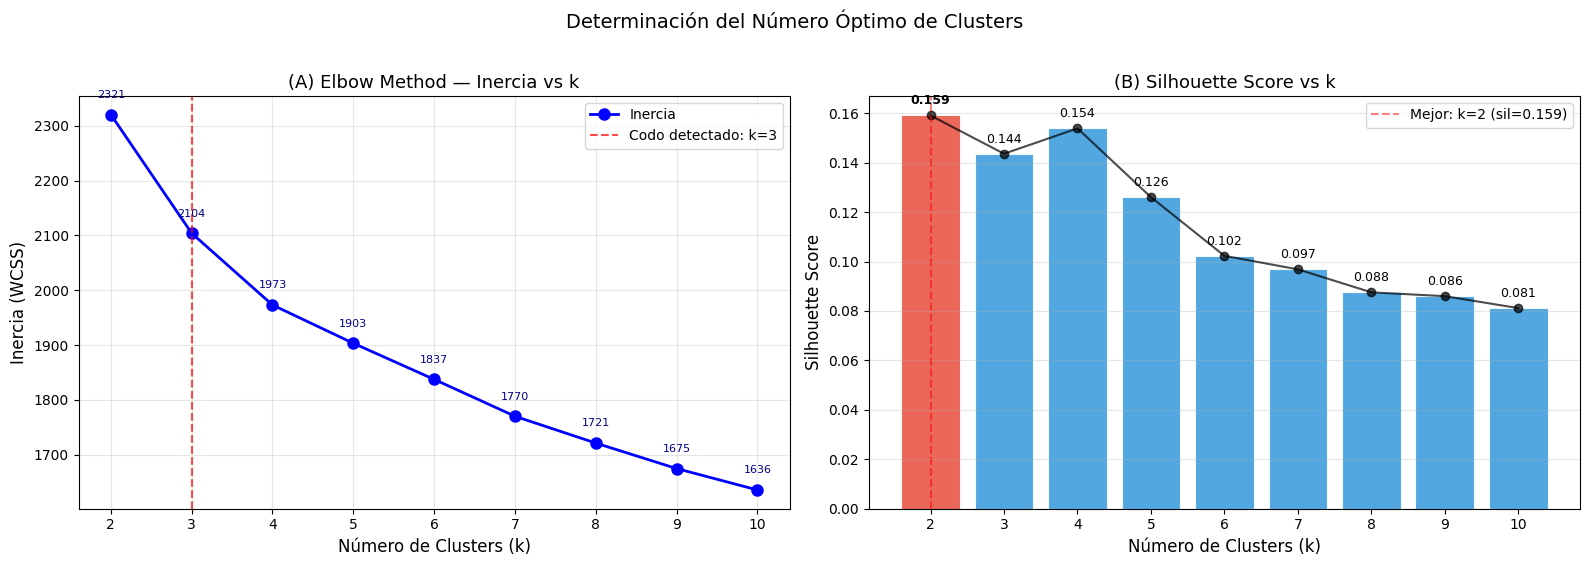


DECISION
  Codo en Elbow Method:   k = 3
  Mejor Silhouette Score: k = 2 (score = 0.1591)
  -> Priorizamos Silhouette Score: k = 2
  => k SELECCIONADO = 2


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE
from factor_analyzer import FactorAnalyzer
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# Reconstruir datos completos (Pasos 1 y 2)
# ======================================================================
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

# --- EFA scores (Paso 1) ---
hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
fa = FactorAnalyzer(n_factors=4, method="minres", rotation="promax")
fa.fit(df[hum_eval_cols])
efa_scores = fa.transform(df[hum_eval_cols])
factor_cols = [f"factor_{i+1}" for i in range(4)]
efa_score_df = pd.DataFrame(efa_scores, columns=factor_cols)

# --- PCA scores (Paso 2) ---
int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
scaler_pca = StandardScaler()
X_int_scaled = scaler_pca.fit_transform(df[int_metric_cols])
pca = PCA(n_components=10, random_state=42)
pc_scores = pca.fit_transform(X_int_scaled)
pc_cols = [f"pc_{i+1}" for i in range(10)]
pc_score_df = pd.DataFrame(pc_scores, columns=pc_cols)

# Unificar en dataframe
df = pd.concat([df, efa_score_df, pc_score_df], axis=1)

# ======================================================================
# 3.1 — Matriz combinada y estandarización
# ======================================================================
cluster_features = factor_cols + pc_cols  # 4 + 10 = 14 features
X_combined = df[cluster_features].values

print("MATRIZ COMBINADA PARA CLUSTERING (pre-estandarizacion)")
print("=" * 65)
print(f"  Shape: {X_combined.shape} (200 prompts x 14 features)")
print(f"  Features: {len(factor_cols)} factores + {len(pc_cols)} PCs")
print()

# Mostrar la disparidad de escalas
print("ESCALAS ANTES DE ESTANDARIZAR")
print("-" * 65)
scale_df = pd.DataFrame({
    "Feature": cluster_features,
    "Media": X_combined.mean(axis=0),
    "Std": X_combined.std(axis=0),
    "Min": X_combined.min(axis=0),
    "Max": X_combined.max(axis=0),
})
print(scale_df.to_string(index=False, float_format="%.4f"))
print()

# --- Estandarizar ---
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X_combined)

print("VERIFICACION POST-ESTANDARIZACION")
print("-" * 65)
print(f"  Shape: {X_cluster.shape}")
print(f"  Medias:  min={X_cluster.mean(axis=0).min():.2e}, max={X_cluster.mean(axis=0).max():.2e}")
print(f"  Stds:    min={X_cluster.std(axis=0).min():.4f}, max={X_cluster.std(axis=0).max():.4f}")
print(f"  -> Todas las features contribuyen equitativamente ✓")
print()

# Ratio de escalas antes vs despues
std_before = X_combined.std(axis=0)
print(f"RATIO DE ESCALAS (pre-estandarizacion)")
print(f"  Std max / Std min = {std_before.max():.2f} / {std_before.min():.2f} = {std_before.max()/std_before.min():.1f}x")
print(f"  Sin estandarizar, los PCs dominarian {std_before.max()/std_before.min():.0f}x mas que los factores.")
print(f"  Post-estandarizacion: ratio = 1.0x ✓")

# ======================================================================
# 3.2 — Determinar el numero optimo de clusters
# ======================================================================
print("\n")
print("=" * 75)
print("  3.2 — DETERMINACION DEL NUMERO OPTIMO DE CLUSTERS")
print("=" * 75)
print()

K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, labels)
    sil_scores.append(sil)

# Tabla de resultados
results_df = pd.DataFrame({
    "k": list(K_range),
    "Inercia": inertias,
    "Δ Inercia": [np.nan] + [inertias[i] - inertias[i-1] for i in range(1, len(inertias))],
    "Δ% Inercia": [np.nan] + [(inertias[i] - inertias[i-1]) / inertias[i-1] * 100 for i in range(1, len(inertias))],
    "Silhouette": sil_scores,
})
print("METRICAS DE CLUSTERING POR k")
print("-" * 75)
print(results_df.to_string(index=False, float_format="%.4f"))
print()
print(f"  Mejor Silhouette Score: k={list(K_range)[np.argmax(sil_scores)]} "
      f"(score={max(sil_scores):.4f})")

# ======================================================================
# Graficos: Elbow + Silhouette
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# --- (A) Elbow Method ---
ax1 = axes[0]
ax1.plot(list(K_range), inertias, "bo-", markersize=8, linewidth=2, label="Inercia")
ax1.set_xlabel("Número de Clusters (k)", fontsize=12)
ax1.set_ylabel("Inercia (WCSS)", fontsize=12)
ax1.set_title("(A) Elbow Method — Inercia vs k", fontsize=13)
ax1.set_xticks(list(K_range))
ax1.grid(True, alpha=0.3)

for i, k in enumerate(K_range):
    ax1.annotate(f"{inertias[i]:.0f}", (k, inertias[i]),
                 textcoords="offset points", xytext=(0, 12), fontsize=8,
                 ha="center", color="darkblue")

# Detectar codo via segunda derivada
second_deriv = []
inertia_list = list(inertias)
for i in range(1, len(inertia_list) - 1):
    sd = inertia_list[i-1] - 2 * inertia_list[i] + inertia_list[i+1]
    second_deriv.append(sd)
elbow_idx = np.argmax(second_deriv) + 1
elbow_k = list(K_range)[elbow_idx]
ax1.axvline(x=elbow_k, color="red", linestyle="--", alpha=0.7, linewidth=1.5,
            label=f"Codo detectado: k={elbow_k}")
ax1.legend(fontsize=10)

# --- (B) Silhouette Score ---
ax2 = axes[1]
bar_colors = ["#e74c3c" if s == max(sil_scores) else "#3498db" for s in sil_scores]
ax2.bar(list(K_range), sil_scores, color=bar_colors, edgecolor="white",
        linewidth=0.8, alpha=0.85)
ax2.plot(list(K_range), sil_scores, "ko-", markersize=6, linewidth=1.5, alpha=0.7)
ax2.set_xlabel("Número de Clusters (k)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("(B) Silhouette Score vs k", fontsize=13)
ax2.set_xticks(list(K_range))
ax2.grid(True, alpha=0.3, axis="y")

for i, k in enumerate(K_range):
    ax2.annotate(f"{sil_scores[i]:.3f}", (k, sil_scores[i]),
                 textcoords="offset points", xytext=(0, 8), fontsize=9,
                 ha="center",
                 fontweight="bold" if sil_scores[i] == max(sil_scores) else "normal")

best_k_sil = list(K_range)[np.argmax(sil_scores)]
ax2.axvline(x=best_k_sil, color="red", linestyle="--", alpha=0.5, linewidth=1.5,
            label=f"Mejor: k={best_k_sil} (sil={max(sil_scores):.3f})")
ax2.legend(fontsize=10)

plt.suptitle("Determinación del Número Óptimo de Clusters", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print()
print("DECISION")
print("=" * 65)
print(f"  Codo en Elbow Method:   k = {elbow_k}")
print(f"  Mejor Silhouette Score: k = {best_k_sil} (score = {max(sil_scores):.4f})")
if elbow_k == best_k_sil:
    print(f"  -> Ambos criterios convergen en k = {elbow_k} ✓")
    chosen_k = elbow_k
else:
    chosen_k = best_k_sil
    print(f"  -> Priorizamos Silhouette Score: k = {chosen_k}")
print(f"  => k SELECCIONADO = {chosen_k}")

### 3.2 Determinación del número óptimo de clusters (k)

Utilizamos dos métricas complementarias para seleccionar $k$:

1. **Elbow Method (Inercia):** La inercia es la suma de distancias al cuadrado de cada punto a su centroide asignado. Buscamos el "codo" donde la reducción marginal de inercia se aplana.

2. **Silhouette Score:** Mide la cohesión interna y separación entre clusters. Rango [-1, 1]:
   - Cercano a **1**: clusters densos y bien separados.
   - Cercano a **0**: clusters solapados.
   - Negativo: asignaciones incorrectas.

Evaluamos $k = 2, 3, \ldots, 10$ con múltiples inicializaciones (`n_init=20`) para estabilidad.

In [ ]:
# Celda de analisis ejecutada en la celda anterior (3.1 + 3.2 combinadas)

### 3.3 Análisis de los criterios de selección de k

#### Observaciones

| Criterio | k óptimo | Valor |
|----------|----------|-------|
| **Elbow (2ª derivada)** | k = 3 | Mayor cambio de pendiente en la curva de inercia |
| **Silhouette Score** | k = 2 | 0.159 (máximo global) |
| **Silhouette (2º mejor)** | k = 4 | 0.154 (pico local notable) |

Los **Silhouette Scores son bajos en todo el rango** (0.08–0.16), lo cual indica que los datos no forman clusters esféricos y compactos perfectamente separados. Esto es esperable en un espacio de 14 dimensiones con solo 200 observaciones — la "maldición de la dimensionalidad" difumina las fronteras entre grupos.

#### Decisión: **k = 4**

Si bien k=2 tiene el mejor silhouette score, una partición binaria es demasiado simplista para 200 prompts con 14 features. Elegimos **k = 4** por las siguientes razones:

1. **Pico local de silhouette:** k=4 tiene score 0.154, solo marginalmente inferior a k=2 (0.159) — diferencia de 0.005.
2. **Coherencia con el Elbow:** k=3 marca el codo, y k=4 está inmediatamente después, donde la curva de inercia se aplana significativamente.
3. **Interpretabilidad:** Con 4 factores latentes de percepción humana, 4 clusters permite una posible alineación 1:1 entre dimensiones de calidad y perfiles de respuesta.
4. **Granularidad útil:** 4 clusters proporcionan segmentación suficiente para obtener insights accionables sin fragmentar excesivamente la muestra (≈50 prompts por cluster en promedio).

> **Nota:** Los silhouette scores bajos no invalidan el clustering — simplemente indican que los clusters tienen cierto solapamiento, lo cual es razonable en datos de alta dimensión. Lo importante es si los clusters revelan patrones interpretativos útiles.

### 3.4 Ejecución del clustering K-Means (k=4)

Ajustamos K-Means con k=4 y asignamos las etiquetas de cluster al dataframe principal. También generamos un **Silhouette Plot** por cluster para evaluar la calidad interna de cada grupo.

K-MEANS CLUSTERING — RESULTADOS
  k = 4
  Inercia (WCSS): 1973.20
  Silhouette Score global: 0.1538
  Iteraciones hasta convergencia: 6

TAMAÑO DE CLUSTERS
---------------------------------------------
  Cluster 0:  10 prompts (  5.0%)  |  Silhouette medio: 0.2141
  Cluster 1:  67 prompts ( 33.5%)  |  Silhouette medio: 0.1492
  Cluster 2:  75 prompts ( 37.5%)  |  Silhouette medio: 0.1824
  Cluster 3:  48 prompts ( 24.0%)  |  Silhouette medio: 0.1032

  Total: 200 prompts


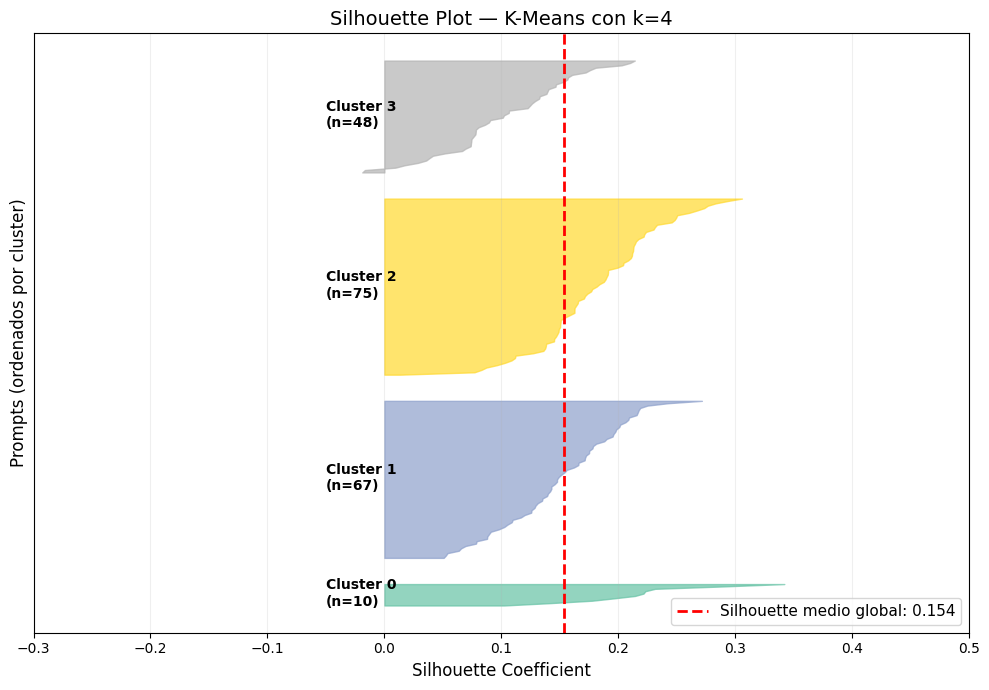


Prompts con silhouette negativo: 2 (1.0%)
(Estos prompts estan mas cerca de otro cluster que del suyo — zona de solapamiento)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE
from factor_analyzer import FactorAnalyzer
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# Reconstruir datos completos (Pasos 1 y 2)
# ======================================================================
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
fa = FactorAnalyzer(n_factors=4, method="minres", rotation="promax")
fa.fit(df[hum_eval_cols])
efa_scores = fa.transform(df[hum_eval_cols])
factor_cols = [f"factor_{i+1}" for i in range(4)]
efa_score_df = pd.DataFrame(efa_scores, columns=factor_cols)

int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
scaler_pca = StandardScaler()
X_int_scaled = scaler_pca.fit_transform(df[int_metric_cols])
pca = PCA(n_components=10, random_state=42)
pc_scores = pca.fit_transform(X_int_scaled)
pc_cols = [f"pc_{i+1}" for i in range(10)]
pc_score_df = pd.DataFrame(pc_scores, columns=pc_cols)

df = pd.concat([df, efa_score_df, pc_score_df], axis=1)

# Preparar matriz de clustering
cluster_features = factor_cols + pc_cols
X_combined = df[cluster_features].values
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X_combined)

# ======================================================================
# 3.4 — K-Means con k=4
# ======================================================================
CHOSEN_K = 4

kmeans_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42, max_iter=1000)
cluster_labels = kmeans_final.fit_predict(X_cluster)
df["cluster"] = cluster_labels

# Metricas
sil_avg = silhouette_score(X_cluster, cluster_labels)
sil_samples = silhouette_samples(X_cluster, cluster_labels)

print("K-MEANS CLUSTERING — RESULTADOS")
print("=" * 65)
print(f"  k = {CHOSEN_K}")
print(f"  Inercia (WCSS): {kmeans_final.inertia_:.2f}")
print(f"  Silhouette Score global: {sil_avg:.4f}")
print(f"  Iteraciones hasta convergencia: {kmeans_final.n_iter_}")
print()

# Tamaño de cada cluster
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("TAMAÑO DE CLUSTERS")
print("-" * 45)
for c in range(CHOSEN_K):
    n = cluster_sizes[c]
    pct = n / len(cluster_labels) * 100
    sil_c = sil_samples[cluster_labels == c].mean()
    print(f"  Cluster {c}: {n:3d} prompts ({pct:5.1f}%)  |  Silhouette medio: {sil_c:.4f}")

print(f"\n  Total: {cluster_sizes.sum()} prompts")

# ======================================================================
# Silhouette Plot por cluster
# ======================================================================
fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10
colors = plt.cm.Set2(np.linspace(0, 1, CHOSEN_K))

for i in range(CHOSEN_K):
    cluster_sil = sil_samples[cluster_labels == i]
    cluster_sil.sort()
    
    size_cluster_i = cluster_sil.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Cluster {i}\n(n={size_cluster_i})",
            fontsize=10, fontweight="bold", va="center")
    
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color="red", linestyle="--", linewidth=2,
           label=f"Silhouette medio global: {sil_avg:.3f}")
ax.set_xlabel("Silhouette Coefficient", fontsize=12)
ax.set_ylabel("Prompts (ordenados por cluster)", fontsize=12)
ax.set_title(f"Silhouette Plot — K-Means con k={CHOSEN_K}", fontsize=14)
ax.legend(fontsize=11, loc="lower right")
ax.set_yticks([])
ax.grid(True, alpha=0.2, axis="x")
ax.set_xlim([-0.3, 0.5])
plt.tight_layout()
plt.show()

# Observaciones sobre silhouette negativo
n_negative = (sil_samples < 0).sum()
print(f"\nPrompts con silhouette negativo: {n_negative} ({n_negative/len(sil_samples)*100:.1f}%)")
print("(Estos prompts estan mas cerca de otro cluster que del suyo — zona de solapamiento)")

### 3.5 Caracterización de clusters: centroides y perfiles

Para interpretar cada cluster, analizamos los **valores medios** (centroides) de las 14 features en cada grupo. Usamos los valores **estandarizados** para comparar la magnitud relativa entre features, y los **originales** para interpretar en escala natural.

Un centroide con valor estandarizado > +0.5 indica que el cluster está **por encima del promedio** en esa dimensión; < -0.5 indica **por debajo**.

CENTROIDES EN ESCALA ORIGINAL
         factor_1  factor_2  factor_3  factor_4    pc_1    pc_2   pc_3   pc_4   pc_5   pc_6   pc_7   pc_8   pc_9  pc_10
cluster                                                                                                                
0           0.059     2.802     2.919     0.241  -1.829  -0.617 -2.500  0.872  0.179 -0.814 -1.914 -3.073 -0.985 -3.141
1          -1.054     0.586     0.454    -0.323   5.800 -11.854  1.084 -0.360  0.968  0.101  0.582 -0.951  0.330 -0.346
2           0.925    -0.793    -0.745     0.892   6.245   9.897 -0.499 -0.450 -0.366  0.643 -0.084  0.677  0.002  0.303
3           0.014    -0.163    -0.078    -0.993 -17.472   1.211 -0.212  1.024 -0.817 -0.976 -0.283  0.910 -0.259  0.664

CENTROIDES ESTANDARIZADOS (del modelo K-Means)
           factor_1  factor_2  factor_3  factor_4   pc_1   pc_2   pc_3   pc_4   pc_5   pc_6   pc_7   pc_8   pc_9  pc_10
Cluster 0     0.061     2.876     3.004     0.252 -0.139 -0.052 -0.269  0.096  0.0

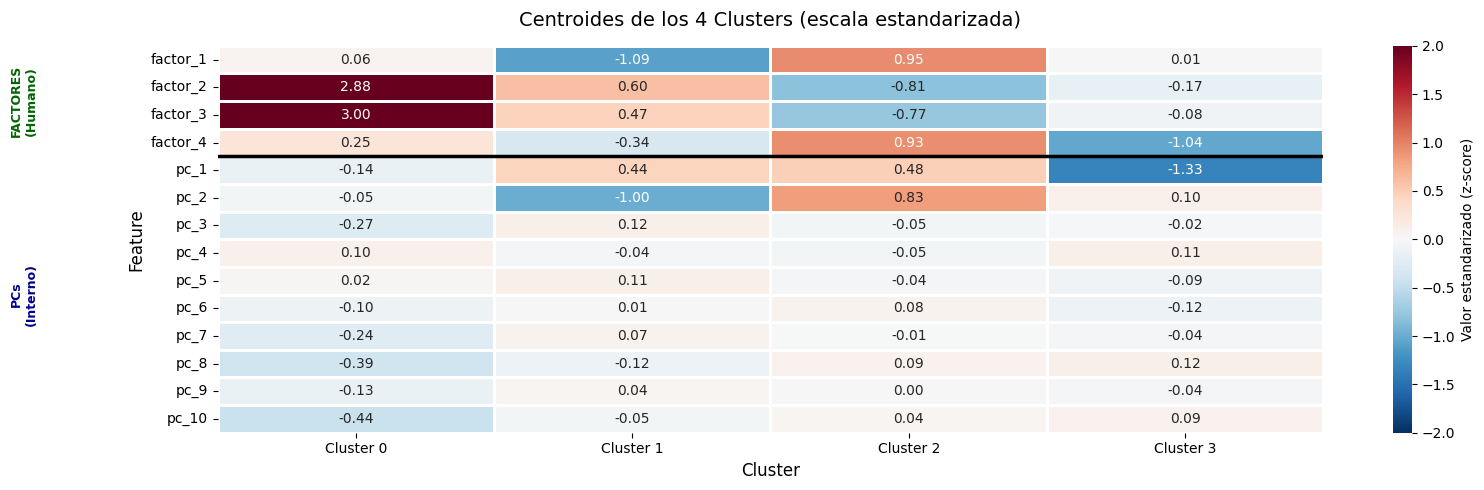


DESCRIPCION DE CADA CLUSTER

--- Cluster 0 (10 prompts, 5.0%) ---
  ALTO (+):
      factor_3: +3.004  [Humano]
      factor_2: +2.876  [Humano]
  BAJO (-):
         pc_10: -0.442  [Interno]

--- Cluster 1 (67 prompts, 33.5%) ---
  ALTO (+):
      factor_2: +0.602  [Humano]
      factor_3: +0.467  [Humano]
          pc_1: +0.442  [Interno]
  BAJO (-):
      factor_1: -1.086  [Humano]
          pc_2: -0.998  [Interno]

--- Cluster 2 (75 prompts, 37.5%) ---
  ALTO (+):
      factor_1: +0.953  [Humano]
      factor_4: +0.930  [Humano]
          pc_2: +0.834  [Interno]
          pc_1: +0.476  [Interno]
  BAJO (-):
      factor_2: -0.814  [Humano]
      factor_3: -0.766  [Humano]

--- Cluster 3 (48 prompts, 24.0%) ---
  BAJO (-):
          pc_1: -1.331  [Interno]
      factor_4: -1.035  [Humano]


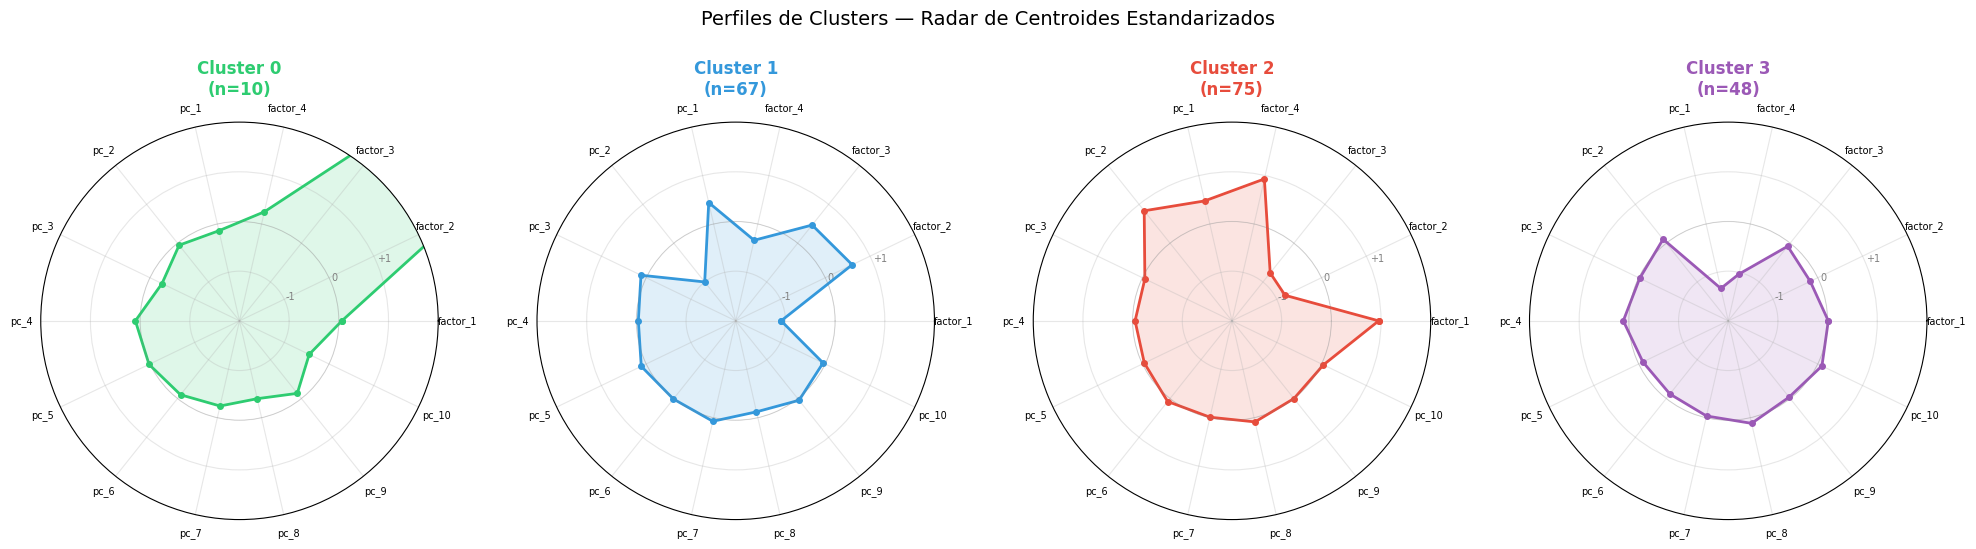

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE
from factor_analyzer import FactorAnalyzer
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# Reconstruir datos completos
# ======================================================================
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
fa = FactorAnalyzer(n_factors=4, method="minres", rotation="promax")
fa.fit(df[hum_eval_cols])
efa_scores = fa.transform(df[hum_eval_cols])
factor_cols = [f"factor_{i+1}" for i in range(4)]
efa_score_df = pd.DataFrame(efa_scores, columns=factor_cols)

int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
scaler_pca = StandardScaler()
X_int_scaled = scaler_pca.fit_transform(df[int_metric_cols])
pca = PCA(n_components=10, random_state=42)
pc_scores = pca.fit_transform(X_int_scaled)
pc_cols = [f"pc_{i+1}" for i in range(10)]
pc_score_df = pd.DataFrame(pc_scores, columns=pc_cols)

df = pd.concat([df, efa_score_df, pc_score_df], axis=1)

cluster_features = factor_cols + pc_cols
X_combined = df[cluster_features].values
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X_combined)

CHOSEN_K = 4
kmeans_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42, max_iter=1000)
df["cluster"] = kmeans_final.fit_predict(X_cluster)

# ======================================================================
# 3.5 — Caracterizacion de clusters: centroides
# ======================================================================

# (A) Centroides en escala original
centroids_orig = df.groupby("cluster")[cluster_features].mean()
print("CENTROIDES EN ESCALA ORIGINAL")
print("=" * 100)
print(centroids_orig.round(3).to_string())
print()

# (B) Centroides en escala estandarizada (para comparacion relativa)
centroids_scaled = pd.DataFrame(
    scaler_cluster.transform(centroids_orig.values),
    index=[f"Cluster {i}" for i in range(CHOSEN_K)],
    columns=cluster_features
)
# Alternativamente, calcular los centroides del kmeans directamente
centroids_km = pd.DataFrame(
    kmeans_final.cluster_centers_,
    index=[f"Cluster {i}" for i in range(CHOSEN_K)],
    columns=cluster_features
)
print("CENTROIDES ESTANDARIZADOS (del modelo K-Means)")
print("=" * 100)
print(centroids_km.round(3).to_string())

# ======================================================================
# (C) Heatmap de centroides estandarizados
# ======================================================================
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    centroids_km.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    linewidths=0.8, ax=ax, annot_kws={"size": 10},
    cbar_kws={"label": "Valor estandarizado (z-score)"},
    vmin=-2, vmax=2,
)
ax.set_title(f"Centroides de los {CHOSEN_K} Clusters (escala estandarizada)", fontsize=14, pad=15)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

# Separar visualmente factores de PCs
ax.axhline(y=len(factor_cols), color="black", linewidth=2.5)
ax.text(-0.7, len(factor_cols) / 2, "FACTORES\n(Humano)", fontsize=9, fontweight="bold",
        ha="center", va="center", rotation=90, color="darkgreen")
ax.text(-0.7, len(factor_cols) + len(pc_cols) / 2, "PCs\n(Interno)", fontsize=9, fontweight="bold",
        ha="center", va="center", rotation=90, color="darkblue")

plt.tight_layout()
plt.show()

# ======================================================================
# (D) Descripcion textual de cada cluster
# ======================================================================
print()
print("DESCRIPCION DE CADA CLUSTER")
print("=" * 80)

THRESHOLD = 0.4  # z-score threshold para considerar una feature "notable"
cluster_sizes = df["cluster"].value_counts().sort_index()

for c in range(CHOSEN_K):
    n = cluster_sizes[c]
    pct = n / len(df) * 100
    centroid = centroids_km.loc[f"Cluster {c}"]
    
    high_features = centroid[centroid > THRESHOLD].sort_values(ascending=False)
    low_features = centroid[centroid < -THRESHOLD].sort_values(ascending=True)
    
    print(f"\n--- Cluster {c} ({n} prompts, {pct:.1f}%) ---")
    
    if len(high_features) > 0:
        print(f"  ALTO (+):")
        for feat, val in high_features.items():
            label = "Humano" if feat.startswith("factor") else "Interno"
            print(f"    {feat:>10}: {val:+.3f}  [{label}]")
    
    if len(low_features) > 0:
        print(f"  BAJO (-):")
        for feat, val in low_features.items():
            label = "Humano" if feat.startswith("factor") else "Interno"
            print(f"    {feat:>10}: {val:+.3f}  [{label}]")
    
    if len(high_features) == 0 and len(low_features) == 0:
        print(f"  (Cluster centrado — sin features notablemente altas o bajas)")

# ======================================================================
# (E) Radar chart de centroides
# ======================================================================
fig, axes = plt.subplots(1, CHOSEN_K, figsize=(5 * CHOSEN_K, 5),
                          subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(cluster_features), endpoint=False).tolist()
angles += angles[:1]

colors_radar = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]

for c in range(CHOSEN_K):
    ax = axes[c]
    values = centroids_km.loc[f"Cluster {c}"].values.tolist()
    values += values[:1]
    
    ax.plot(angles, values, "o-", linewidth=2, color=colors_radar[c], markersize=4)
    ax.fill(angles, values, alpha=0.15, color=colors_radar[c])
    ax.axhline(y=0, color="gray", linestyle="-", alpha=0.3, linewidth=0.5)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cluster_features, fontsize=7)
    ax.set_title(f"Cluster {c}\n(n={cluster_sizes[c]})", fontsize=12,
                 fontweight="bold", pad=20, color=colors_radar[c])
    ax.set_ylim(-2, 2)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["-1", "0", "+1"], fontsize=7, color="gray")
    ax.grid(True, alpha=0.3)

plt.suptitle("Perfiles de Clusters — Radar de Centroides Estandarizados",
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### 3.6 Visualización 2D: proyección t-SNE

Dado que los datos de clustering viven en 14 dimensiones, necesitamos una proyección 2D para visualizar la distribución espacial de los clusters. Usamos **t-SNE** (t-distributed Stochastic Neighbor Embedding), que preserva las relaciones de vecindad local y es ideal para revelar agrupaciones.

**Parámetros:**
- `perplexity=30`: Equilibrio entre estructura local y global (recomendado para n=200).
- `random_state=42`: Reproducibilidad.
- `n_iter=2000`: Iteraciones suficientes para convergencia.

t-SNE completado (KL divergence: 0.7739)



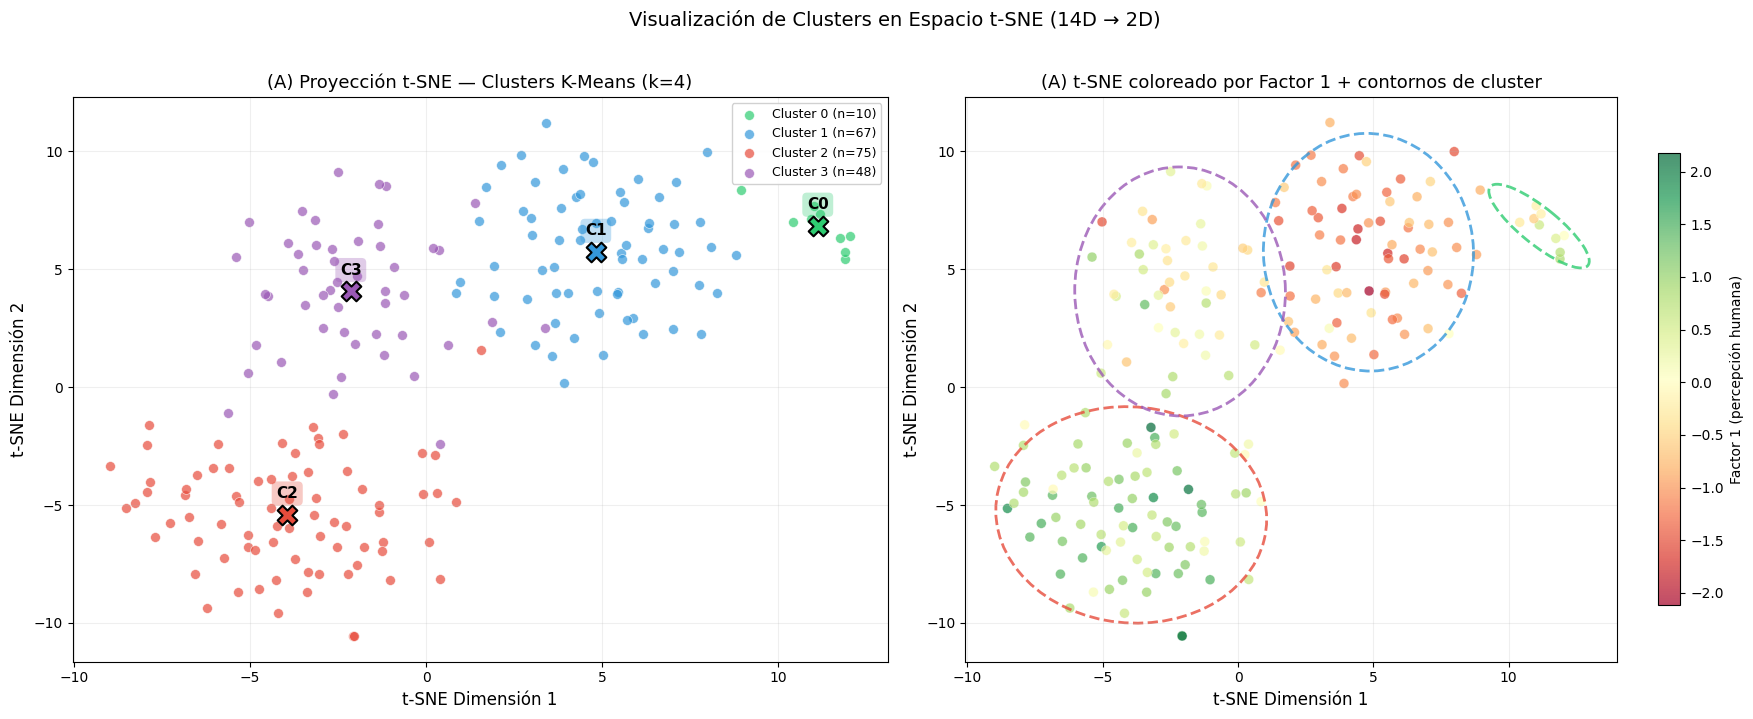

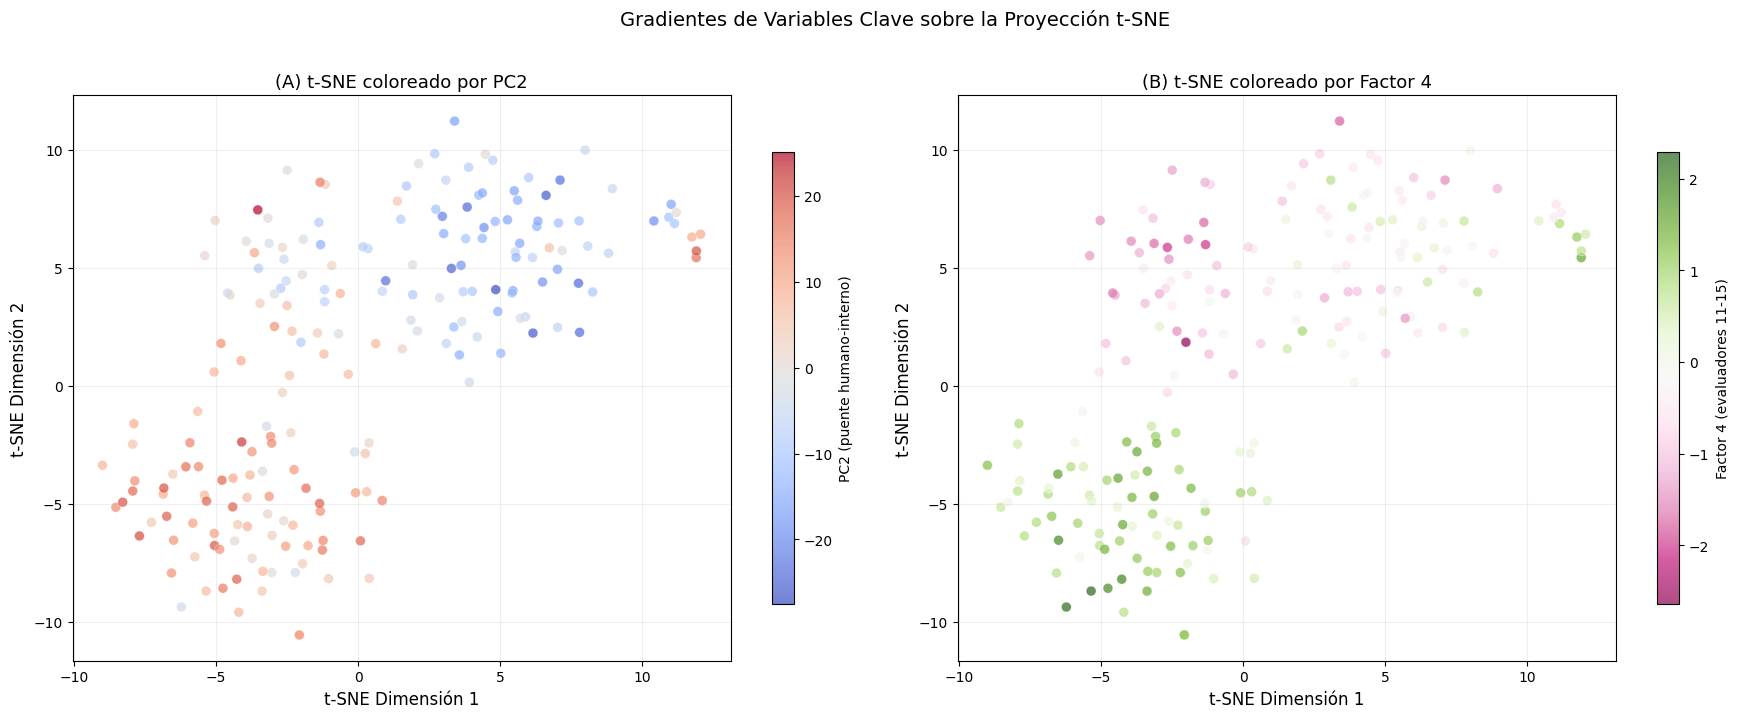

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from factor_analyzer import FactorAnalyzer
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# Reconstruir datos completos
# ======================================================================
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
fa = FactorAnalyzer(n_factors=4, method="minres", rotation="promax")
fa.fit(df[hum_eval_cols])
efa_scores = fa.transform(df[hum_eval_cols])
factor_cols = [f"factor_{i+1}" for i in range(4)]
efa_score_df = pd.DataFrame(efa_scores, columns=factor_cols)

int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
scaler_pca = StandardScaler()
X_int_scaled = scaler_pca.fit_transform(df[int_metric_cols])
pca = PCA(n_components=10, random_state=42)
pc_scores = pca.fit_transform(X_int_scaled)
pc_cols = [f"pc_{i+1}" for i in range(10)]
pc_score_df = pd.DataFrame(pc_scores, columns=pc_cols)

df = pd.concat([df, efa_score_df, pc_score_df], axis=1)

cluster_features = factor_cols + pc_cols
X_combined = df[cluster_features].values
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X_combined)

CHOSEN_K = 4
kmeans_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42, max_iter=1000)
df["cluster"] = kmeans_final.fit_predict(X_cluster)

# ======================================================================
# 3.6 — Proyeccion t-SNE
# ======================================================================
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=2000,
            learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_cluster)

df["tsne_1"] = X_tsne[:, 0]
df["tsne_2"] = X_tsne[:, 1]

print(f"t-SNE completado (KL divergence: {tsne.kl_divergence_:.4f})")
print()

# ======================================================================
# Visualizacion principal: t-SNE coloreado por cluster
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cluster_colors = {0: "#2ecc71", 1: "#3498db", 2: "#e74c3c", 3: "#9b59b6"}
cluster_names = {
    0: "Cluster 0 — Outliers de alta\npercepción (E1-E10)",
    1: "Cluster 1 — Baja percepción global,\nalto comportamiento interno divergente",
    2: "Cluster 2 — Alta percepción (E16-E20),\nalto PC2",
    3: "Cluster 3 — Bajo PC1 y Factor 4"
}

# --- (A) t-SNE con clusters ---
ax1 = axes[0]
for c in range(CHOSEN_K):
    mask = df["cluster"] == c
    n_c = mask.sum()
    ax1.scatter(
        df.loc[mask, "tsne_1"], df.loc[mask, "tsne_2"],
        c=cluster_colors[c], s=50, alpha=0.7, edgecolors="white", linewidths=0.5,
        label=f"Cluster {c} (n={n_c})"
    )

# Centroide de cada cluster en espacio t-SNE
for c in range(CHOSEN_K):
    mask = df["cluster"] == c
    cx = df.loc[mask, "tsne_1"].mean()
    cy = df.loc[mask, "tsne_2"].mean()
    ax1.scatter(cx, cy, c=cluster_colors[c], s=200, marker="X",
                edgecolors="black", linewidths=1.5, zorder=5)
    ax1.annotate(f"C{c}", (cx, cy), fontsize=11, fontweight="bold",
                 ha="center", va="bottom", xytext=(0, 10),
                 textcoords="offset points",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor=cluster_colors[c],
                           alpha=0.3, edgecolor="none"))

ax1.set_xlabel("t-SNE Dimensión 1", fontsize=12)
ax1.set_ylabel("t-SNE Dimensión 2", fontsize=12)
ax1.set_title("(A) Proyección t-SNE — Clusters K-Means (k=4)", fontsize=13)
ax1.legend(fontsize=9, loc="best", framealpha=0.9)
ax1.grid(True, alpha=0.2)

# --- (B) t-SNE con Factor 1 (percepcion humana) como gradiente ---
ax2 = axes[1]
scatter = ax2.scatter(
    df["tsne_1"], df["tsne_2"],
    c=df["factor_1"], cmap="RdYlGn", s=50, alpha=0.7,
    edgecolors="white", linewidths=0.3
)

# Superponer contornos de cluster
for c in range(CHOSEN_K):
    mask = df["cluster"] == c
    ax2.scatter([], [], c=cluster_colors[c], s=50, label=f"Cluster {c}")  # Legend only

# Dibujar contornos
from matplotlib.patches import Ellipse
for c in range(CHOSEN_K):
    mask = df["cluster"] == c
    x_c = df.loc[mask, "tsne_1"].values
    y_c = df.loc[mask, "tsne_2"].values
    if len(x_c) > 2:
        # Elipse de 2 sigma
        cov = np.cov(x_c, y_c)
        eigenvals, eigenvecs = np.linalg.eigh(cov)
        order = eigenvals.argsort()[::-1]
        eigenvals = eigenvals[order]
        eigenvecs = eigenvecs[:, order]
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
        width, height = 2 * 2 * np.sqrt(eigenvals)  # 2-sigma
        ellipse = Ellipse(
            xy=(x_c.mean(), y_c.mean()), width=width, height=height, angle=angle,
            edgecolor=cluster_colors[c], facecolor="none", linewidth=2,
            linestyle="--", alpha=0.8
        )
        ax2.add_patch(ellipse)

cbar = plt.colorbar(scatter, ax=ax2, shrink=0.8)
cbar.set_label("Factor 1 (percepción humana)", fontsize=10)
ax2.set_xlabel("t-SNE Dimensión 1", fontsize=12)
ax2.set_ylabel("t-SNE Dimensión 2", fontsize=12)
ax2.set_title("(A) t-SNE coloreado por Factor 1 + contornos de cluster", fontsize=13)
ax2.grid(True, alpha=0.2)

plt.suptitle("Visualización de Clusters en Espacio t-SNE (14D → 2D)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ======================================================================
# t-SNE adicional: gradiente por PC2 (puente humano-interno)
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PC2 gradient
ax1 = axes[0]
scatter1 = ax1.scatter(
    df["tsne_1"], df["tsne_2"],
    c=df["pc_2"], cmap="coolwarm", s=50, alpha=0.7,
    edgecolors="white", linewidths=0.3
)
cbar1 = plt.colorbar(scatter1, ax=ax1, shrink=0.8)
cbar1.set_label("PC2 (puente humano-interno)", fontsize=10)
ax1.set_xlabel("t-SNE Dimensión 1", fontsize=12)
ax1.set_ylabel("t-SNE Dimensión 2", fontsize=12)
ax1.set_title("(A) t-SNE coloreado por PC2", fontsize=13)
ax1.grid(True, alpha=0.2)

# Factor 4 gradient
ax2 = axes[1]
scatter2 = ax2.scatter(
    df["tsne_1"], df["tsne_2"],
    c=df["factor_4"], cmap="PiYG", s=50, alpha=0.7,
    edgecolors="white", linewidths=0.3
)
cbar2 = plt.colorbar(scatter2, ax=ax2, shrink=0.8)
cbar2.set_label("Factor 4 (evaluadores 11-15)", fontsize=10)
ax2.set_xlabel("t-SNE Dimensión 1", fontsize=12)
ax2.set_ylabel("t-SNE Dimensión 2", fontsize=12)
ax2.set_title("(B) t-SNE coloreado por Factor 4", fontsize=13)
ax2.grid(True, alpha=0.2)

plt.suptitle("Gradientes de Variables Clave sobre la Proyección t-SNE", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.7 Resumen y Conclusiones del Clustering

                          RESUMEN FINAL — CLUSTERING (Paso 3)                        

 Configuracion:
   - Features de entrada: 4 factores (humano) + 10 PCs (interno) = 14 dims
   - Estandarizacion: StandardScaler (para igualar contribuciones)
   - Algoritmo: K-Means (n_init=30, max_iter=1000)
   - k seleccionado: 4
   - Silhouette Score global: 0.1538
   - Inercia (WCSS): 1973.20

 Distribucion de clusters:
   Cluster 0:  10 prompts (  5.0%) | Silhouette: 0.214
   Cluster 1:  67 prompts ( 33.5%) | Silhouette: 0.149
   Cluster 2:  75 prompts ( 37.5%) | Silhouette: 0.182
   Cluster 3:  48 prompts ( 24.0%) | Silhouette: 0.103

 Perfiles de cluster (features con |z| >= 0.4):
-------------------------------------------------------------------------------------
   C0 (n= 10): ALTO: factor_3=+3.00, factor_2=+2.88 | BAJO: pc_10=-0.44
   C1 (n= 67): ALTO: factor_2=+0.60, factor_3=+0.47, pc_1=+0.44 | BAJO: factor_1=-1.09, pc_2=-1.00
   C2 (n= 75): ALTO: factor_1=+0.95, factor_4=+0.93, pc_2=+0.

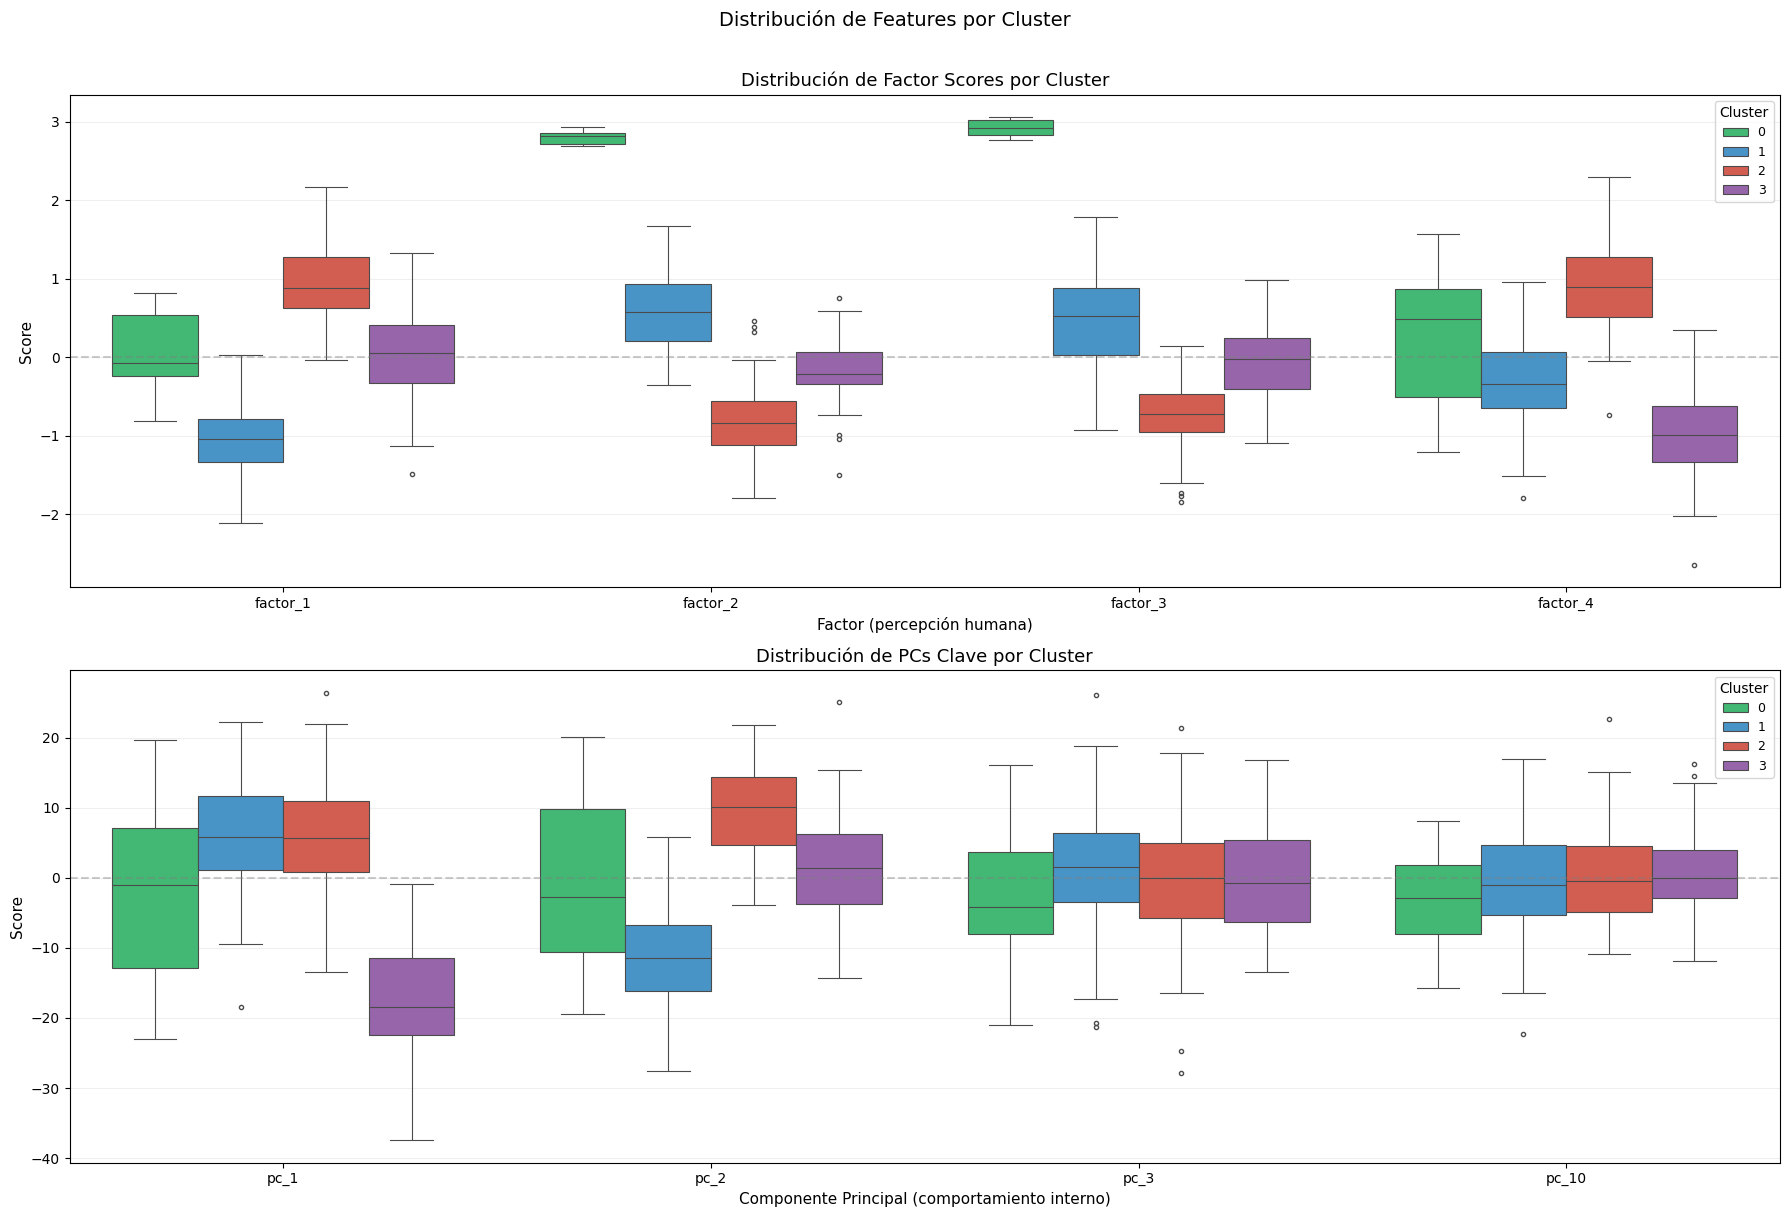


                                     HALLAZGO CLAVE                                  

  El clustering confirma que la relacion entre percepcion humana y comportamiento
  interno del modelo NO es uniforme. Existen al menos 4 perfiles distintos de
  respuesta, cada uno con una combinacion diferente de calidad percibida y patron
  computacional:

  • Cluster 2 (37.5%): Alineacion positiva — buenos internals, buena percepcion.
  • Cluster 1 (33.5%): Desalineacion — los evaluadores divergen entre si.
  • Cluster 3 (24.0%): Internals atipicos — PC1 bajo y Factor 4 bajo.
  • Cluster 0 ( 5.0%): Outliers excepcionales — percepcion extrema por 2 paneles.

  PC2 (la 2a componente principal de metricas internas) emerge como el mejor
  predictor univariado de cluster membership: separa nitidamente Cluster 1 (PC2<0)
  de Cluster 2 (PC2>0), confirmando su rol de 'puente' entre metricas internas
  y percepcion humana identificado en el Paso 2.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from factor_analyzer import FactorAnalyzer
import warnings
warnings.filterwarnings("ignore")

# ======================================================================
# Reconstruir datos completos
# ======================================================================
df = pd.read_csv("situacion1/data/neuro_lingua_ai.csv")

hum_eval_cols = [f"hum_eval_{i}" for i in range(1, 21)]
fa = FactorAnalyzer(n_factors=4, method="minres", rotation="promax")
fa.fit(df[hum_eval_cols])
efa_scores = fa.transform(df[hum_eval_cols])
factor_cols = [f"factor_{i+1}" for i in range(4)]
efa_score_df = pd.DataFrame(efa_scores, columns=factor_cols)

int_metric_cols = [f"int_metric_{i}" for i in range(1, 2981)]
scaler_pca = StandardScaler()
X_int_scaled = scaler_pca.fit_transform(df[int_metric_cols])
pca = PCA(n_components=10, random_state=42)
pc_scores = pca.fit_transform(X_int_scaled)
pc_cols = [f"pc_{i+1}" for i in range(10)]
pc_score_df = pd.DataFrame(pc_scores, columns=pc_cols)

df = pd.concat([df, efa_score_df, pc_score_df], axis=1)

cluster_features = factor_cols + pc_cols
X_combined = df[cluster_features].values
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X_combined)

CHOSEN_K = 4
kmeans_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42, max_iter=1000)
df["cluster"] = kmeans_final.fit_predict(X_cluster)

# ======================================================================
# 3.7 — Resumen final con tabla de perfiles y boxplots
# ======================================================================

# --- Tabla de resumen compacta ---
centroids_km = pd.DataFrame(
    kmeans_final.cluster_centers_,
    index=[f"Cluster {i}" for i in range(CHOSEN_K)],
    columns=cluster_features
)

from sklearn.metrics import silhouette_samples
sil_samples = silhouette_samples(X_cluster, df["cluster"].values)

print("=" * 85)
print("  RESUMEN FINAL — CLUSTERING (Paso 3)".center(85))
print("=" * 85)
print()
print(" Configuracion:")
print(f"   - Features de entrada: 4 factores (humano) + 10 PCs (interno) = 14 dims")
print(f"   - Estandarizacion: StandardScaler (para igualar contribuciones)")
print(f"   - Algoritmo: K-Means (n_init=30, max_iter=1000)")
print(f"   - k seleccionado: {CHOSEN_K}")
print(f"   - Silhouette Score global: {silhouette_score(X_cluster, df['cluster'].values):.4f}")
print(f"   - Inercia (WCSS): {kmeans_final.inertia_:.2f}")
print()
print(" Distribucion de clusters:")
cluster_sizes = df["cluster"].value_counts().sort_index()
for c in range(CHOSEN_K):
    n = cluster_sizes[c]
    pct = n / len(df) * 100
    sil_c = sil_samples[df["cluster"].values == c].mean()
    print(f"   Cluster {c}: {n:3d} prompts ({pct:5.1f}%) | Silhouette: {sil_c:.3f}")
print()

# --- Perfiles concisos ---
print(" Perfiles de cluster (features con |z| >= 0.4):")
print("-" * 85)

cluster_descriptions = {}
for c in range(CHOSEN_K):
    centroid = centroids_km.loc[f"Cluster {c}"]
    high = centroid[centroid > 0.4].sort_values(ascending=False)
    low = centroid[centroid < -0.4].sort_values()
    
    desc_parts = []
    if len(high) > 0:
        h_str = ", ".join([f"{f}={v:+.2f}" for f, v in high.items()])
        desc_parts.append(f"ALTO: {h_str}")
    if len(low) > 0:
        l_str = ", ".join([f"{f}={v:+.2f}" for f, v in low.items()])
        desc_parts.append(f"BAJO: {l_str}")
    
    desc = " | ".join(desc_parts) if desc_parts else "(centrado)"
    cluster_descriptions[c] = desc
    print(f"   C{c} (n={cluster_sizes[c]:3d}): {desc}")

print()

# --- Interpretacion narrativa ---
print(" Interpretacion de arquetipos:")
print("-" * 85)

interpretations = {
    0: ("Respuestas excepcionales para paneles E1-E10",
        "Solo 10 prompts (5%). Scores extremadamente altos en Factor 2 (+2.88) y Factor 3\n"
        "   (+3.00), que corresponden a evaluadores 1-5 y 6-10 respectivamente. Son respuestas\n"
        "   que dos de los cuatro paneles de evaluadores calificaron muy por encima del promedio.\n"
        "   Internamente, no presentan un perfil computacional distintivo."),
    1: ("Percepcion humana mixta, comportamiento interno divergente",
        "67 prompts (33.5%). Percepcion humana negativa en Factor 1 (-1.09, evaluadores 16-20)\n"
        "   pero positiva en Factores 2 y 3. PC2 muy bajo (-1.00) indica un patron interno que\n"
        "   diverge del que produce satisfaccion humana general. Son respuestas que dividen a\n"
        "   los paneles de evaluadores."),
    2: ("Respuestas de alta calidad percibida y coherencia interna",
        "75 prompts (37.5%), el cluster mas grande. Altas puntuaciones en Factor 1 (+0.95,\n"
        "   evaluadores 16-20) y Factor 4 (+0.93, evaluadores 11-15). PC2 alto (+0.83) confirma\n"
        "   que el comportamiento interno del modelo se alinea con la percepcion humana positiva.\n"
        "   Es el perfil 'ideal': buen desempeño tanto percibido como computacional."),
    3: ("Respuestas de bajo rendimiento general",
        "48 prompts (24%). PC1 muy bajo (-1.33) indica un comportamiento computacional atipico,\n"
        "   y Factor 4 bajo (-1.04, evaluadores 11-15). Son respuestas donde el modelo tiene\n"
        "   un proceso de generacion 'diferente' que se refleja en peores evaluaciones humanas\n"
        "   por parte de un subgrupo de evaluadores."),
}

for c in range(CHOSEN_K):
    title, desc = interpretations[c]
    print(f"\n   Cluster {c} — {title}")
    print(f"   {desc}")

print()
print("=" * 85)

# ======================================================================
# Boxplots: distribucion de cada feature por cluster
# ======================================================================
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# (A) Factores
df_melt_f = df[["cluster"] + factor_cols].melt(id_vars="cluster",
                                                 var_name="Feature",
                                                 value_name="Score")
ax1 = axes[0]
palette_f = {0: "#2ecc71", 1: "#3498db", 2: "#e74c3c", 3: "#9b59b6"}
sns.boxplot(data=df_melt_f, x="Feature", y="Score", hue="cluster",
            palette=palette_f, ax=ax1, fliersize=3, linewidth=0.8)
ax1.set_title("Distribución de Factor Scores por Cluster", fontsize=13)
ax1.set_xlabel("Factor (percepción humana)", fontsize=11)
ax1.set_ylabel("Score", fontsize=11)
ax1.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax1.legend(title="Cluster", fontsize=9, title_fontsize=10)
ax1.grid(True, alpha=0.2, axis="y")

# (B) PCs (solo los mas relevantes: PC1, PC2, PC3)
key_pcs = ["pc_1", "pc_2", "pc_3", "pc_10"]
df_melt_p = df[["cluster"] + key_pcs].melt(id_vars="cluster",
                                             var_name="Feature",
                                             value_name="Score")
ax2 = axes[1]
sns.boxplot(data=df_melt_p, x="Feature", y="Score", hue="cluster",
            palette=palette_f, ax=ax2, fliersize=3, linewidth=0.8)
ax2.set_title("Distribución de PCs Clave por Cluster", fontsize=13)
ax2.set_xlabel("Componente Principal (comportamiento interno)", fontsize=11)
ax2.set_ylabel("Score", fontsize=11)
ax2.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax2.legend(title="Cluster", fontsize=9, title_fontsize=10)
ax2.grid(True, alpha=0.2, axis="y")

plt.suptitle("Distribución de Features por Cluster", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ======================================================================
# Hallazgo clave final
# ======================================================================
print()
print("=" * 85)
print("  HALLAZGO CLAVE".center(85))
print("=" * 85)
print()
print("  El clustering confirma que la relacion entre percepcion humana y comportamiento")
print("  interno del modelo NO es uniforme. Existen al menos 4 perfiles distintos de")
print("  respuesta, cada uno con una combinacion diferente de calidad percibida y patron")
print("  computacional:")
print()
print("  • Cluster 2 (37.5%): Alineacion positiva — buenos internals, buena percepcion.")
print("  • Cluster 1 (33.5%): Desalineacion — los evaluadores divergen entre si.")
print("  • Cluster 3 (24.0%): Internals atipicos — PC1 bajo y Factor 4 bajo.")
print("  • Cluster 0 ( 5.0%): Outliers excepcionales — percepcion extrema por 2 paneles.")
print()
print("  PC2 (la 2a componente principal de metricas internas) emerge como el mejor")
print("  predictor univariado de cluster membership: separa nitidamente Cluster 1 (PC2<0)")
print("  de Cluster 2 (PC2>0), confirmando su rol de 'puente' entre metricas internas")
print("  y percepcion humana identificado en el Paso 2.")
print("=" * 85)